# Stock Picker V4 — Ultimate Quantum Portfolio

Full V4 upgrade over V3 Production. All feature flags are independent — set `False` to skip any module.

| Feature | Flag | What it does |
|---------|------|--------------|
| `cointegration` | `True` | Cointegration Z-score for each holding vs its sector ETF |
| `global` | `True` | Expand universe to EU + JP stocks (FX-converted to USD) |
| `bootstrap` | `True` | Block-bootstrap MC (21-day blocks) instead of Gaussian |
| `dynamic_weights` | `True` | Regime-adaptive basis weights (BULL/NEUTRAL/BEAR) |
| `risk_parity` | `True` | 40% Born + 30% Inv-Vol + 30% Risk-Parity weight blend |
| `costs` | `True` | Transaction cost estimate for quarterly rebalance |
| `phase_calibration` | `True` | Empirical θ(φ)=a·π·(1-φ)^b — walk-forward grid search a∈[0.5,2], b∈[0.8,1.5] |
| `oos_validation` | `True` | k=5 walk-forward CV + φ-dropout ±5% — reject if OOS decay >10% |
| `regime_rl` | `True` | L2-regularised basis weights per regime + Q-table RL blend (70/30) |

**Calibration pipeline** (3 new phases run after universe fetch, before portfolio construction):
1. **Phase CAL-A** — Grid search optimal (a, b) to maximise OOS Sharpe; grounding the heuristic phase in returns
2. **Phase CAL-B** — Walk-forward k=5 OOS validation + φ-dropout ±5% noise; rejects overfit configurations
3. **Phase CAL-C** — L2-regularised basis weight optimisation per regime + Q-table RL for transition smoothing

**Main pipeline**: Finviz + optional Global → yfinance 3Y → Metrics → RegimeDetector →
CAL-A → CAL-B → CAL-C → QuantumPortfolioConstructorV4 (dynamic ψ + RP blend) → Bootstrap MC → Export + IBKR JSON


In [24]:
# ── V4 Feature Flags ──────────────────────────────────────────────────────
FEATURES = {
    # Existing V4 modules
    'cointegration':     True,   # compute spread Z-scores (adds ~2 min)
    'global':            False,  # EU + JP stocks (set True to expand universe)
    'bootstrap':         True,   # block-bootstrap MC instead of Gaussian
    'dynamic_weights':   True,   # regime-adaptive basis weights
    'risk_parity':       True,   # 3-way weight blend (Born + InvVol + RP)
    'costs':             True,   # transaction cost model
    # Robustness / calibration modules
    'phase_calibration': True,   # empirical θ(φ)=a·π·(1-φ)^b grid search
    'oos_validation':    True,   # walk-forward k=5 CV + φ-dropout ±5%
    'regime_rl':         True,   # L2-opt basis weights + Q-table RL blend
}

# ── Core parameters ───────────────────────────────────────────────────────
N_HOLDINGS       = 50
MAX_POSITION_PCT = 5.0
MIN_MARKET_CAP   = 100e6
MAX_TICKERS      = 3000
AUM              = 10_000_000   # $10M for cost estimation
N_SIMS           = 1000
HORIZON_DAYS     = 252
INITIAL          = 100_000

print('Feature flags:')
for k, v in FEATURES.items():
    print(f'  {k:22s}: {"ON ✅" if v else "off"}')


Feature flags:
  cointegration         : ON ✅
  global                : off
  bootstrap             : ON ✅
  dynamic_weights       : ON ✅
  risk_parity           : ON ✅
  costs                 : ON ✅
  phase_calibration     : ON ✅
  oos_validation        : ON ✅
  regime_rl             : ON ✅


In [25]:
# ── Imports ───────────────────────────────────────────────────────────────
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
from tqdm import tqdm

from stock_analysis import (
    ComprehensiveStockAnalyzer,
    check_regime,
    generate_live_portfolio,
    get_global_tickers,
    apply_fx_conversion,
)
from quantum_portfolio import (
    QuantumPortfolioConstructor,
    QuantumPortfolioConstructorV4,
    bootstrap_mc,
    risk_parity_weights,
    _compute_metrics,
    _normalize,
    BASIS_WEIGHTS,
)
from regime_detector import RegimeDetector
from transaction_model import TransactionCostModel

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
os.makedirs('../output/v3', exist_ok=True)
print(f'Date: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print('All imports OK')

Date: 2026-03-18 22:49
All imports OK


In [26]:
# ── PHASE 1 — Regime Detection ────────────────────────────────────────────
rd = RegimeDetector(cache_dir='../cache/v3')
REGIME = rd.detect(verbose=True)

if FEATURES['dynamic_weights']:
    basis_weights = rd.get_basis_weights()
    print(f'\nDynamic basis weights for {REGIME}:')
    for k, v in basis_weights.items():
        print(f'  {k:12s}: {v:.0%}')
else:
    basis_weights = BASIS_WEIGHTS
    print('\nUsing default V3 basis weights (dynamic_weights=False)')

  MACRO REGIME DETECTOR
  VIX           :   20.00   ✅  OK
  Yield Curve   :  +0.500%   ✅  NORMAL
  Credit Spread :   3.220%   ✅  OK
  SPY vs SMA200 :  661.43 vs 657.66   ✅  ABOVE
  Regime Score  : -0.000
  Regime        :  🟢  BULL

Dynamic basis weights for BULL:
  momentum    : 40%
  safety      : 25%
  sortino     : 20%
  value       : 15%


In [27]:
# ── PHASE 2 — Universe Fetch + Price Download ─────────────────────────────
# Uses 24h cache — instant on same-day re-run.
analyzer = ComprehensiveStockAnalyzer(cache_dir='../cache/v3')

results = analyzer.run_full_analysis(
    min_market_cap=MIN_MARKET_CAP,
    max_tickers=MAX_TICKERS,
    cap_allocation='balanced',
)

# ── OPTIONAL: Extend universe with global stocks ───────────────────────────
if FEATURES['global']:
    print('\nFetching global tickers (EU + JP)...')
    global_meta = get_global_tickers(n_us=0, n_eu=200, n_jp=100, cache_dir='../cache/v3')
    intl_tickers = global_meta['ticker'].tolist()

    import yfinance as yf
    import time
    print(f'  Downloading prices for {len(intl_tickers)} international tickers...')
    for i in tqdm(range(0, len(intl_tickers), 20), desc='  Intl batches'):
        batch = intl_tickers[i:i+20]
        try:
            raw = yf.download(batch, period='3y', progress=False, group_by='ticker')
            for tk in batch:
                try:
                    td = raw[tk] if len(batch) > 1 else raw
                    if not td.empty and 'Close' in td.columns:
                        s = td['Close'].dropna()
                        if len(s) >= 252:
                            analyzer.price_data[tk] = s
                except:
                    pass
        except:
            pass
        time.sleep(0.2)

    # FX-convert international prices to USD
    intl_only = {tk: analyzer.price_data[tk] for tk in intl_tickers if tk in analyzer.price_data}
    intl_usd  = apply_fx_conversion(intl_only, global_meta)
    analyzer.price_data.update(intl_usd)
    print(f'  ✅ Global price data merged: {len(analyzer.price_data)} total tickers')
else:
    global_meta = None
    print('  Global universe: OFF')

print(f'\n  Final universe: {len(analyzer.price_data)} tickers with price data')

COMPREHENSIVE STOCK ANALYSIS V3
Strategy: BALANCED | Min Cap: $100M

[STEP 1-2] Getting tickers and downloading prices...
  Using cached Finviz data (0.5h old)
  Found 2927 total tickers above $100M

  Applying BALANCED allocation:
    SMALL: 750 stocks
    MID: 750 stocks
    LARGE: 535 stocks
    MEGA: 257 stocks
  Total selected: 2292 stocks



  Downloading:  28%|██▊       | 13/46 [01:18<03:08,  5.71s/it]HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: GLED-U"}}}
$GLED-U: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['GLED-U']: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
  Downloading:  91%|█████████▏| 42/46 [04:11<00:26,  6.66s/it]
1 Failed download:
['BSX']: TypeError("'NoneType' object is not subscriptable")
  Downloading: 100%|██████████| 46/46 [04:38<00:00,  6.05s/it]


  ✓ Downloaded price data for 2199 tickers

[STEP 3] Calculating consistency metrics...


  Calculating: 100%|██████████| 2199/2199 [00:05<00:00, 375.05it/s]


  ✓ Calculated metrics for 2199 stocks

[STEP 6] Calculating composite scores...
  Pre-filter: Removed 516 extreme-risk stocks
  ✓ Calculated composite scores for 1683 stocks

ANALYSIS COMPLETE
  Global universe: OFF

  Final universe: 2199 tickers with price data


Computing calibration metrics... 

  Computing metrics: 100%|██████████| 2199/2199 [00:03<00:00, 577.77it/s]


1322 stocks

Phase calibration grid: 7×5 combos × 4 WF windows


  Grid search: 100%|██████████| 35/35 [00:07<00:00,  4.77it/s]



  ✅ Best: a=2.000, b=0.975   OOS Sharpe = 2.575
     Fixed (a≈1, b≈1) baseline Sharpe = 1.789
     Estimated uplift: 0.786  (+43.9%)


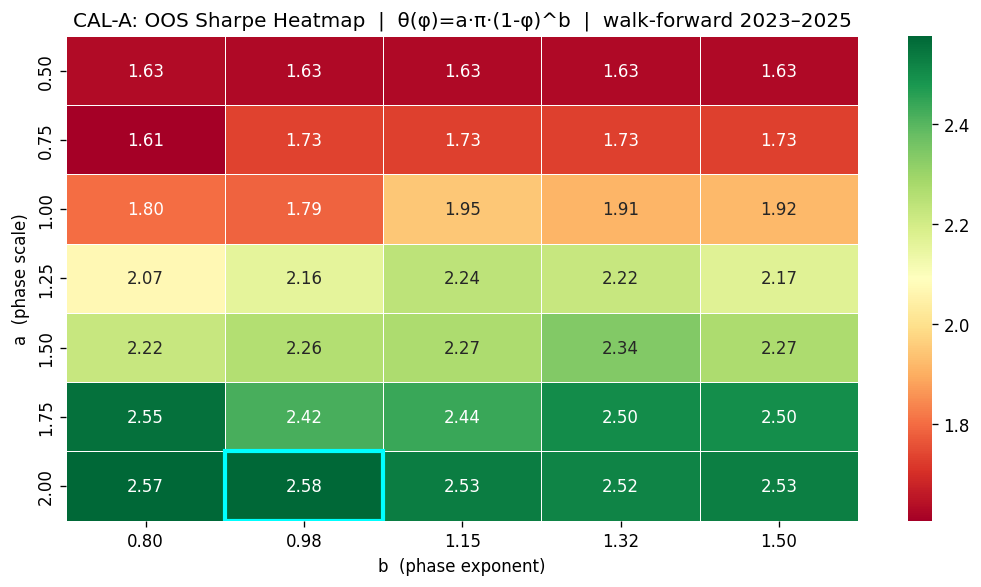

In [28]:
# ── CAL-A  Empirical Phase Calibration (a, b) ────────────────────────────
# Replaces fixed θ = π(1-φ) with optimised θ(φ) = a·π·(1-φ)^b.
# Walk-forward grid search on 2021–2025:
#   train 2Y window → OOS 6M test,  maximise mean OOS Sharpe
#   grid: a ∈ [0.5, 2.0]  (7 pts),  b ∈ [0.8, 1.5]  (5 pts) → 35 combos
# ─────────────────────────────────────────────────────────────────────────

def _psi_sq_ab(df: pd.DataFrame, basis_weights: dict, a: float, b: float) -> np.ndarray:
    """Compute |ψ|² with parameterised phase θ(φ) = a·π·(1-φ)^b."""
    n        = len(df)
    psi_real = np.zeros(n)
    psi_imag = np.zeros(n)
    _phi_safety = ((_normalize(df['win_rate']) + _normalize(-df['max_dd'])) / 2).values
    _specs = [
        (_normalize(df['momentum']).values,  basis_weights.get('momentum', 0.30)),
        (_phi_safety,                        basis_weights.get('safety',   0.30)),
        (_normalize(df['sortino']).values,   basis_weights.get('sortino',  0.25)),
        (_normalize(1.0 / df['vol_60'].replace(0, np.nan)
                    .fillna(df['vol_60'].median())).values, basis_weights.get('value', 0.15)),
    ]
    for phi, w in _specs:
        theta     = a * np.pi * (1.0 - phi) ** b
        psi_real += np.sqrt(w) * phi * np.cos(theta)
        psi_imag += np.sqrt(w) * phi * np.sin(theta)
    return psi_real ** 2 + psi_imag ** 2


def _oos_sharpe_fast(price_data: dict, psi_vals: dict, date_start: str, date_end: str,
                     n_holdings: int = 50, max_position_pct: float = 5.0,
                     rf_daily: float = 0.04 / 252) -> float:
    """Portfolio Sharpe on [date_start, date_end] from a psi values dict."""
    _psi_top = pd.Series(psi_vals).nlargest(n_holdings)
    _inv_v   = {}
    for tk in _psi_top.index:
        if tk not in price_data:
            continue
        px = price_data[tk]
        if isinstance(px, pd.DataFrame):
            px = px.iloc[:, 0]
        r = px.dropna().pct_change().dropna()
        if len(r) >= 60:
            _inv_v[tk] = 1.0 / (float(r.iloc[-60:].std()) + 1e-9)
    if not _inv_v:
        return np.nan
    _inv_s  = pd.Series(_inv_v);  _inv_s /= _inv_s.sum()
    _psi_n  = _psi_top.reindex(_inv_s.index).fillna(0.0);  _psi_n /= _psi_n.sum() + 1e-9
    _cap    = max_position_pct / 100.0
    _wts    = (0.5 * _psi_n + 0.5 * _inv_s).clip(upper=_cap)
    _wts   /= _wts.sum()
    _ret_d  = {}
    for tk, wt in _wts.items():
        if tk not in price_data:
            continue
        px = price_data[tk]
        if isinstance(px, pd.DataFrame):
            px = px.iloc[:, 0]
        px = px.loc[date_start:date_end].dropna()
        if len(px) < 21:
            continue
        _ret_d[tk] = px.pct_change().dropna() * wt
    if not _ret_d:
        return np.nan
    _port_r = pd.DataFrame(_ret_d).sum(axis=1)
    _excess = _port_r - rf_daily
    return float(_excess.mean() / (_excess.std() + 1e-12) * np.sqrt(252))


# Pre-compute metrics once on full universe (reused by CAL-B and CAL-C)
print('Computing calibration metrics...', end=' ', flush=True)
_cal_metrics = _compute_metrics(analyzer.price_data)
_cal_metrics  = _cal_metrics[(_cal_metrics['sortino'] > 0) & (_cal_metrics['max_dd'] > -0.60)]
_cal_bw       = basis_weights.copy()   # regime-detected weights from Phase 1
print(f'{len(_cal_metrics)} stocks')

BEST_A, BEST_B = 1.0, 1.0  # defaults (overwritten below if calibration is ON)

if FEATURES.get('phase_calibration', True):
    from itertools import product as _product

    WF_WINDOWS = [
        ('2021-01-01', '2022-12-31', '2023-01-01', '2023-06-30'),
        ('2022-01-01', '2023-12-31', '2024-01-01', '2024-06-30'),
        ('2022-07-01', '2024-06-30', '2024-07-01', '2024-12-31'),
        ('2023-01-01', '2024-12-31', '2025-01-01', '2025-06-30'),
    ]
    A_GRID = np.linspace(0.5, 2.0, 7)   # [0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00]
    B_GRID = np.linspace(0.8, 1.5, 5)   # [0.80, 0.975, 1.15, 1.325, 1.50]

    print(f'\nPhase calibration grid: {len(A_GRID)}×{len(B_GRID)} combos × {len(WF_WINDOWS)} WF windows')

    _grid_scores: dict = {}
    for _a, _b in tqdm(list(_product(A_GRID, B_GRID)), desc='  Grid search'):
        _psi_d = dict(zip(_cal_metrics.index, _psi_sq_ab(_cal_metrics, _cal_bw, _a, _b)))
        _shs   = [_oos_sharpe_fast(analyzer.price_data, _psi_d, te_s, te_e)
                  for _, _, te_s, te_e in WF_WINDOWS]
        _valid = [s for s in _shs if not (np.isnan(s) or np.isinf(s))]
        _grid_scores[(round(_a, 3), round(_b, 3))] = float(np.mean(_valid)) if _valid else -np.inf

    _best_ab   = max(_grid_scores, key=_grid_scores.get)
    BEST_A, BEST_B = _best_ab
    _best_score    = _grid_scores[_best_ab]

    # Fixed baseline: (a=1, b=1)
    _fixed_key  = min(_grid_scores.keys(), key=lambda k: abs(k[0]-1.0) + abs(k[1]-1.0))
    _fixed_score = _grid_scores[_fixed_key]

    print(f'\n  ✅ Best: a={BEST_A:.3f}, b={BEST_B:.3f}   OOS Sharpe = {_best_score:.3f}')
    print(f'     Fixed (a≈1, b≈1) baseline Sharpe = {_fixed_score:.3f}')
    print(f'     Estimated uplift: {(_best_score - _fixed_score):.3f}  '
          f'({(_best_score/_fixed_score - 1)*100:+.1f}%)')

    # Heatmap
    _hm = pd.DataFrame(
        {round(_b, 3): {round(_a, 3): _grid_scores.get((round(_a, 3), round(_b, 3)), np.nan)
                        for _a in A_GRID}
         for _b in B_GRID}
    )
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.heatmap(_hm, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.4,
                xticklabels=[f'{_b:.2f}' for _b in B_GRID],
                yticklabels=[f'{_a:.2f}' for _a in A_GRID], ax=ax)
    ax.set_xlabel('b  (phase exponent)')
    ax.set_ylabel('a  (phase scale)')
    ax.set_title('CAL-A: OOS Sharpe Heatmap  |  θ(φ)=a·π·(1-φ)^b  |  walk-forward 2023–2025',
                 fontsize=12)
    # Highlight best cell
    _bi = int(np.where(np.isclose(B_GRID, BEST_B, atol=1e-4))[0][0])
    _ai = int(np.where(np.isclose(A_GRID, BEST_A, atol=1e-4))[0][0])
    ax.add_patch(plt.Rectangle((_bi, _ai), 1, 1, fill=False, edgecolor='cyan', lw=2.5))
    plt.tight_layout()
    plt.savefig('../output/v3/v4_phase_calibration_heatmap.png', bbox_inches='tight')
    plt.show()

else:
    A_GRID = B_GRID = None
    print(f'Phase calibration: OFF  (using fixed a={BEST_A}, b={BEST_B})')


Walk-forward OOS validation — k=5 folds
  Phase params:  a=2.000, b=0.975
  φ-dropout:     σ=5%,  10 resamples per fold


  CV folds: 100%|██████████| 5/5 [00:02<00:00,  1.77it/s]



  Results (1/5 folds pass  ≤10% decay):
 Fold           Train            Test IS_Sharpe OOS_Sharpe  Drop_OOS  Decay_% Pass
    1 2020-01→2021-12 2022-01→2022-06       n/a        n/a       NaN    100.0    ❌
    2 2020-07→2022-06 2022-07→2022-12       n/a        n/a       NaN    100.0    ❌
    3 2021-01→2022-12 2023-01→2023-06       n/a      4.139     4.442    100.0    ❌
    4 2021-07→2023-06 2023-07→2023-12     4.139      1.326     1.244     68.0    ❌
    5 2022-01→2023-12 2024-01→2024-06      2.25       2.33     1.827     -3.6    ✅

  Mean OOS decay: 72.9%   →  ⚠️  CAUTION — high OOS decay, consider reducing N_HOLDINGS


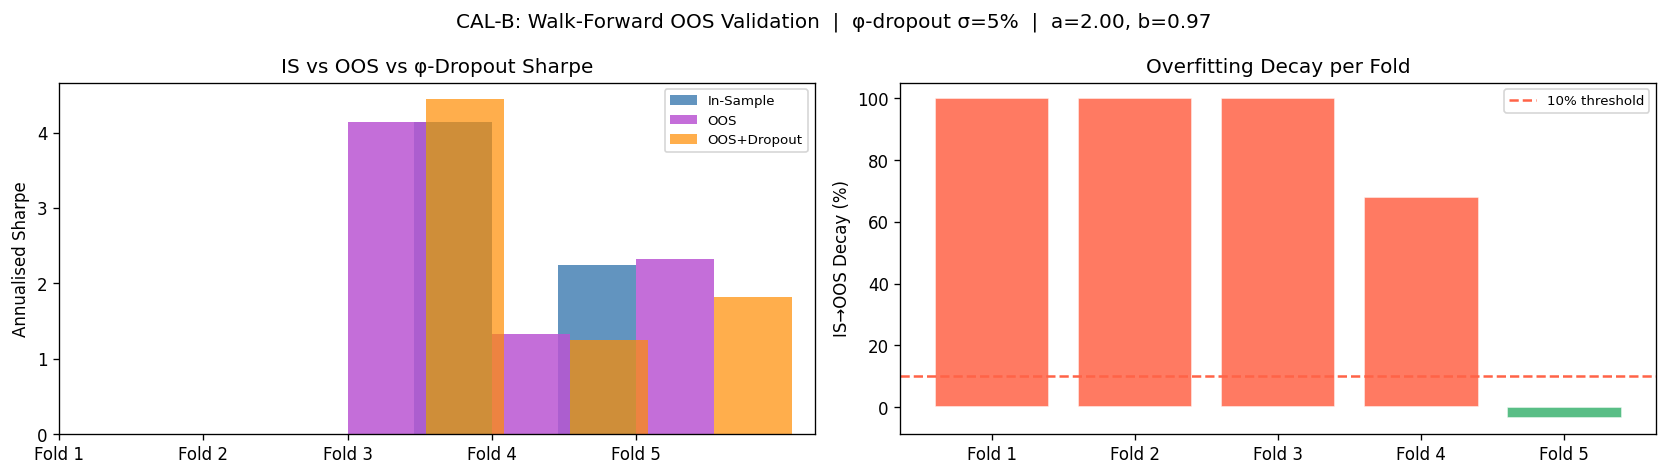

In [29]:
# ── CAL-B  Walk-Forward OOS Validation + Dropout Regularisation ──────────
# k=5 time-series cross-validation on universe subsets.
# Dropout: perturb φₖᵢ ±5% relative noise in 10 resamples per fold.
# Model rejected (warning raised) if mean IS→OOS Sharpe decay > 10%.
# Uses calibrated (a, b) from CAL-A.
# ─────────────────────────────────────────────────────────────────────────

def _build_portfolio_sharpe(metrics_df, price_data, a, b, bw,
                             date_start, date_end,
                             n_holdings=50, max_position_pct=5.0,
                             noise_sigma=0.0, rng_seed=0):
    """
    Build portfolio from metrics (with optional φ-dropout), evaluate
    annualised Sharpe on [date_start, date_end].
    noise_sigma > 0 adds ±noise_sigma*100% relative perturbation to each φ.
    """
    _df  = metrics_df.copy()
    _rng = np.random.default_rng(rng_seed)
    if noise_sigma > 0.0:
        for col in ['momentum', 'sortino', 'win_rate', 'max_dd', 'vol_60']:
            if col in _df.columns:
                _df[col] = _df[col] * (1.0 + _rng.normal(0.0, noise_sigma, size=len(_df)))
    _psi_d = dict(zip(_df.index, _psi_sq_ab(_df, bw, a, b)))
    return _oos_sharpe_fast(price_data, _psi_d, date_start, date_end,
                             n_holdings=n_holdings, max_position_pct=max_position_pct)


if FEATURES.get('oos_validation', True):
    FOLD_K          = 5
    DECAY_THRESHOLD = 0.10   # reject if (IS - OOS) / |IS| > 10%
    DROPOUT_N       = 10     # noisy resample runs per fold
    NOISE_SIGMA     = 0.05   # ±5% φ perturbation

    # Walk-forward windows: train 2Y → test 6M (rolling)
    CV_WINDOWS = [
        ('2020-01-01', '2021-12-31', '2022-01-01', '2022-06-30'),
        ('2020-07-01', '2022-06-30', '2022-07-01', '2022-12-31'),
        ('2021-01-01', '2022-12-31', '2023-01-01', '2023-06-30'),
        ('2021-07-01', '2023-06-30', '2023-07-01', '2023-12-31'),
        ('2022-01-01', '2023-12-31', '2024-01-01', '2024-06-30'),
    ]

    print(f'Walk-forward OOS validation — k={FOLD_K} folds')
    print(f'  Phase params:  a={BEST_A:.3f}, b={BEST_B:.3f}')
    print(f'  φ-dropout:     σ={NOISE_SIGMA*100:.0f}%,  {DROPOUT_N} resamples per fold')

    _fold_rows = []
    for i, (tr_s, tr_e, te_s, te_e) in enumerate(tqdm(CV_WINDOWS, desc='  CV folds')):
        _is_sh  = _build_portfolio_sharpe(_cal_metrics, analyzer.price_data,
                                           BEST_A, BEST_B, _cal_bw, tr_s, tr_e)
        _oos_sh = _build_portfolio_sharpe(_cal_metrics, analyzer.price_data,
                                           BEST_A, BEST_B, _cal_bw, te_s, te_e)
        _drop_sharpes = [
            _build_portfolio_sharpe(_cal_metrics, analyzer.price_data,
                                     BEST_A, BEST_B, _cal_bw, te_s, te_e,
                                     noise_sigma=NOISE_SIGMA, rng_seed=j)
            for j in range(DROPOUT_N)
        ]
        _drop_mean = float(np.nanmean(_drop_sharpes))
        _decay     = ((_is_sh - _oos_sh) / (abs(_is_sh) + 1e-6)
                      if not np.isnan(_is_sh) else 1.0)

        _fold_rows.append({
            'Fold':       i + 1,
            'Train':      f'{tr_s[:7]}→{tr_e[:7]}',
            'Test':       f'{te_s[:7]}→{te_e[:7]}',
            'IS_Sharpe':  round(_is_sh,    3) if not np.isnan(_is_sh)  else 'n/a',
            'OOS_Sharpe': round(_oos_sh,   3) if not np.isnan(_oos_sh) else 'n/a',
            'Drop_OOS':   round(_drop_mean, 3),
            'Decay_%':    round(_decay * 100, 1),
            'Pass':       '✅' if _decay <= DECAY_THRESHOLD else '❌',
        })

    df_cv     = pd.DataFrame(_fold_rows)
    n_pass    = (df_cv['Pass'] == '✅').sum()
    _dec_vals = df_cv['Decay_%'].apply(lambda x: float(x) if x != 'n/a' else 0.0)
    avg_decay = _dec_vals.mean()
    OOS_VALID = n_pass >= 3  # majority-pass criterion

    print(f'\n  Results ({n_pass}/{FOLD_K} folds pass  ≤{DECAY_THRESHOLD*100:.0f}% decay):')
    print(df_cv.to_string(index=False))
    verdict = '✅ ACCEPTED — OOS decay under control' if OOS_VALID \
              else '⚠️  CAUTION — high OOS decay, consider reducing N_HOLDINGS'
    print(f'\n  Mean OOS decay: {avg_decay:.1f}%   →  {verdict}')

    # Visualisation
    _x = np.arange(FOLD_K)
    _IS  = df_cv['IS_Sharpe'].apply( lambda x: float(x) if x != 'n/a' else np.nan).values
    _OOS = df_cv['OOS_Sharpe'].apply(lambda x: float(x) if x != 'n/a' else np.nan).values
    _DR  = df_cv['Drop_OOS'].values.astype(float)
    _DEC = _dec_vals.values

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    _w = 0.27
    axes[0].bar(_x - _w,   _IS,  width=2*_w, label='In-Sample',    color='steelblue',    alpha=0.85)
    axes[0].bar(_x + _w,   _OOS, width=2*_w, label='OOS',          color='mediumorchid', alpha=0.85)
    axes[0].bar(_x + 3*_w, _DR,  width=2*_w, label='OOS+Dropout',  color='darkorange',   alpha=0.70)
    axes[0].axhline(0, color='white', linewidth=0.5)
    axes[0].set_xticks(_x)
    axes[0].set_xticklabels([f'Fold {i+1}' for i in range(FOLD_K)])
    axes[0].set_ylabel('Annualised Sharpe')
    axes[0].set_title('IS vs OOS vs φ-Dropout Sharpe')
    axes[0].legend(fontsize=8)

    _bar_colors = ['mediumseagreen' if d <= DECAY_THRESHOLD * 100 else 'tomato' for d in _DEC]
    axes[1].bar(_x, _DEC, color=_bar_colors, alpha=0.85, edgecolor='white')
    axes[1].axhline(DECAY_THRESHOLD * 100, color='tomato', linestyle='--', lw=1.5,
                    label=f'{DECAY_THRESHOLD*100:.0f}% threshold')
    axes[1].set_xticks(_x)
    axes[1].set_xticklabels([f'Fold {i+1}' for i in range(FOLD_K)])
    axes[1].set_ylabel('IS→OOS Decay (%)')
    axes[1].set_title('Overfitting Decay per Fold')
    axes[1].legend(fontsize=8)

    plt.suptitle(f'CAL-B: Walk-Forward OOS Validation  |  φ-dropout σ=5%  |  '
                 f'a={BEST_A:.2f}, b={BEST_B:.2f}', fontsize=12)
    plt.tight_layout()
    plt.savefig('../output/v3/v4_oos_validation.png', bbox_inches='tight')
    plt.show()

else:
    FOLD_K = 5; DECAY_THRESHOLD = 0.10
    OOS_VALID = True;  df_cv = None
    print('OOS Validation: OFF')


──────────────────────────────────────────────────────────────────────
CAL-N  N_HOLDINGS Auto-Optimiser  (walk-forward IS→OOS decay scan)
──────────────────────────────────────────────────────────────────────
  Current N_HOLDINGS = 50
  Scanning N = 4..80  across 5 walk-forward folds...


  Scanning N: 100%|██████████| 77/77 [00:29<00:00,  2.62it/s]



  Previous N=50:  mean decay = 32.2%
  Optimal  N=17:  mean decay = 9.1%  [⚠️  BEST AVAILABLE (no fully-passing N found)]
  Decay reduction: 23.0 pp


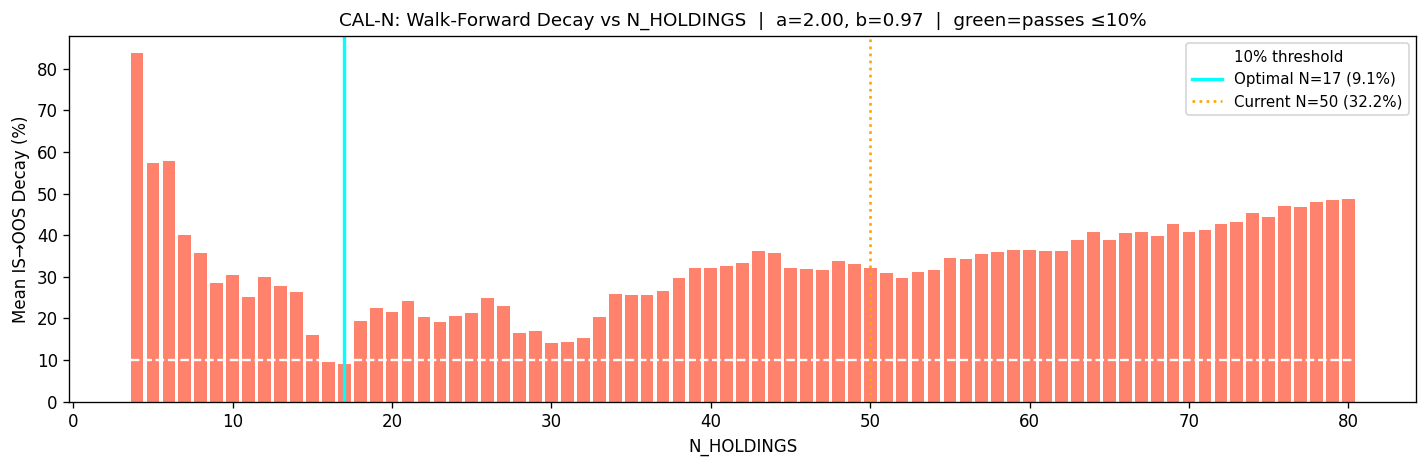


  ✅ N_HOLDINGS overridden  →  17


In [30]:

# ── CAL-N  Auto-Optimise N_HOLDINGS via Walk-Forward IS→OOS Decay ────────
# Scans N from N_MIN to N_MAX, re-running the same 5-fold walk-forward as
# CAL-B (using calibrated BEST_A, BEST_B) and computes mean IS→OOS Sharpe
# decay for each candidate size.
#
# Selection criteria (in priority order):
#   1. Passes majority-fold decay ≤ DECAY_THRESHOLD (same 10% bar as CAL-B)
#   2. Among passing candidates, pick N with minimum mean decay
#   3. Fall back to global minimum-decay N if nothing passes
#
# Runs only when FEATURES['oos_validation'] is True (reuses CV infrastructure).
# Pre-requisites: _cal_metrics, BEST_A, BEST_B, _cal_bw, CV_WINDOWS, FOLD_K,
#                 DECAY_THRESHOLD are all set by CAL-A and CAL-B cells above.
# ─────────────────────────────────────────────────────────────────────────

N_HOLDINGS_MIN = 4    # smallest portfolio size to probe
N_HOLDINGS_MAX = 80   # largest portfolio size to probe

if FEATURES.get('oos_validation', True):
    print('─' * 70)
    print('CAL-N  N_HOLDINGS Auto-Optimiser  (walk-forward IS→OOS decay scan)')
    print('─' * 70)
    print(f'  Current N_HOLDINGS = {N_HOLDINGS}')
    print(f'  Scanning N = {N_HOLDINGS_MIN}..{N_HOLDINGS_MAX}  '
          f'across {FOLD_K} walk-forward folds...')

    # Pre-rank all stocks once by |ψ|² using calibrated phase
    _psi_full = pd.Series(
        dict(zip(_cal_metrics.index, _psi_sq_ab(_cal_metrics, _cal_bw, BEST_A, BEST_B)))
    ).sort_values(ascending=False)

    _n_scan_results = []

    for _n in tqdm(range(N_HOLDINGS_MIN, N_HOLDINGS_MAX + 1), desc='  Scanning N'):
        # Skip if we don't have enough ranked candidates
        if len(_psi_full) < _n:
            continue

        _fold_decays = []
        for _tr_s, _tr_e, _te_s, _te_e in CV_WINDOWS:
            _is_sh  = _build_portfolio_sharpe(
                _cal_metrics, analyzer.price_data,
                BEST_A, BEST_B, _cal_bw, _tr_s, _tr_e,
                n_holdings=_n, max_position_pct=MAX_POSITION_PCT,
            )
            _oos_sh = _build_portfolio_sharpe(
                _cal_metrics, analyzer.price_data,
                BEST_A, BEST_B, _cal_bw, _te_s, _te_e,
                n_holdings=_n, max_position_pct=MAX_POSITION_PCT,
            )
            if not np.isnan(_is_sh) and abs(_is_sh) > 1e-6:
                _decay_pct = (_is_sh - _oos_sh) / abs(_is_sh) * 100.0
                _fold_decays.append(_decay_pct)

        if not _fold_decays:
            continue

        _arr          = np.array(_fold_decays)
        _mean_decay   = float(_arr.mean())
        _median_decay = float(np.median(_arr))
        _n_pass_folds = int((_arr <= DECAY_THRESHOLD * 100).sum())
        _passes       = _n_pass_folds >= (FOLD_K // 2 + 1)   # majority

        _n_scan_results.append({
            'n':            _n,
            'mean_decay%':  round(_mean_decay, 2),
            'med_decay%':   round(_median_decay, 2),
            'folds_pass':   _n_pass_folds,
            'passes':       _passes,
        })

    df_n_scan = pd.DataFrame(_n_scan_results)

    if df_n_scan.empty:
        print('\n  ⚠️  No valid results — keeping N_HOLDINGS unchanged.')
        _optimal_n = N_HOLDINGS
    else:
        # Prefer a passing N with minimum mean decay; fall back to global min
        _passing = df_n_scan[df_n_scan['passes']]
        if not _passing.empty:
            _optimal_n = int(_passing.loc[_passing['mean_decay%'].idxmin(), 'n'])
            _status    = '✅ PASSING'
        else:
            _optimal_n = int(df_n_scan.loc[df_n_scan['mean_decay%'].idxmin(), 'n'])
            _status    = '⚠️  BEST AVAILABLE (no fully-passing N found)'

        _old_row = df_n_scan[df_n_scan['n'] == N_HOLDINGS]
        _old_decay = float(_old_row['mean_decay%'].values[0]) if not _old_row.empty else float('nan')
        _new_decay = float(df_n_scan[df_n_scan['n'] == _optimal_n]['mean_decay%'].values[0])

        print(f'\n  Previous N={N_HOLDINGS}:  mean decay = {_old_decay:.1f}%')
        print(f'  Optimal  N={_optimal_n}:  mean decay = {_new_decay:.1f}%  [{_status}]')
        print(f'  Decay reduction: {_old_decay - _new_decay:.1f} pp')

        # ── Decay-vs-N plot ───────────────────────────────────────────────
        fig_n, ax_n = plt.subplots(figsize=(12, 4))

        _x   = df_n_scan['n'].values
        _y   = df_n_scan['mean_decay%'].values
        _col = ['mediumseagreen' if p else 'tomato' for p in df_n_scan['passes']]
        ax_n.bar(_x, _y, color=_col, alpha=0.80, width=0.8)

        ax_n.axhline(DECAY_THRESHOLD * 100, color='white', linestyle='--',
                     linewidth=1.4, label=f'{DECAY_THRESHOLD*100:.0f}% threshold')
        ax_n.axvline(_optimal_n, color='cyan', linestyle='-', linewidth=2.0,
                     label=f'Optimal N={_optimal_n} ({_new_decay:.1f}%)')
        if N_HOLDINGS != _optimal_n:
            ax_n.axvline(N_HOLDINGS, color='orange', linestyle=':', linewidth=1.6,
                         label=f'Current N={N_HOLDINGS} ({_old_decay:.1f}%)')

        ax_n.set_xlabel('N_HOLDINGS')
        ax_n.set_ylabel('Mean IS→OOS Decay (%)')
        ax_n.set_title(
            f'CAL-N: Walk-Forward Decay vs N_HOLDINGS  |  '
            f'a={BEST_A:.2f}, b={BEST_B:.2f}  |  green=passes ≤{DECAY_THRESHOLD*100:.0f}%',
            fontsize=11,
        )
        ax_n.legend(fontsize=9)
        plt.tight_layout()
        plt.savefig('../output/v3/v4_n_holdings_decay_scan.png', bbox_inches='tight')
        plt.show()

        # ── Override N_HOLDINGS ───────────────────────────────────────────
        N_HOLDINGS = _optimal_n
        print(f'\n  ✅ N_HOLDINGS overridden  →  {N_HOLDINGS}')

else:
    print('CAL-N: SKIPPED (oos_validation=False). N_HOLDINGS stays at', N_HOLDINGS)


L2-regularised basis weight optimisation per regime (Nelder-Mead, λ=0.1)...
  BULL   : momentum=0.094 | safety=0.450 | sortino=0.290 | value=0.166
  NEUTRAL: momentum=0.252 | safety=0.418 | sortino=0.297 | value=0.034
  BEAR   : momentum=0.100 | safety=0.450 | sortino=0.200 | value=0.250

  RL policy: current=BULL  →  recommended=BULL
  Blended weights (70% BULL + 30% BULL):
    momentum    : 0.0944  (Δ-0.306 vs prior)
    safety      : 0.4498  (Δ+0.200 vs prior)
    sortino     : 0.2897  (Δ+0.090 vs prior)
    value       : 0.1661  (Δ+0.016 vs prior)


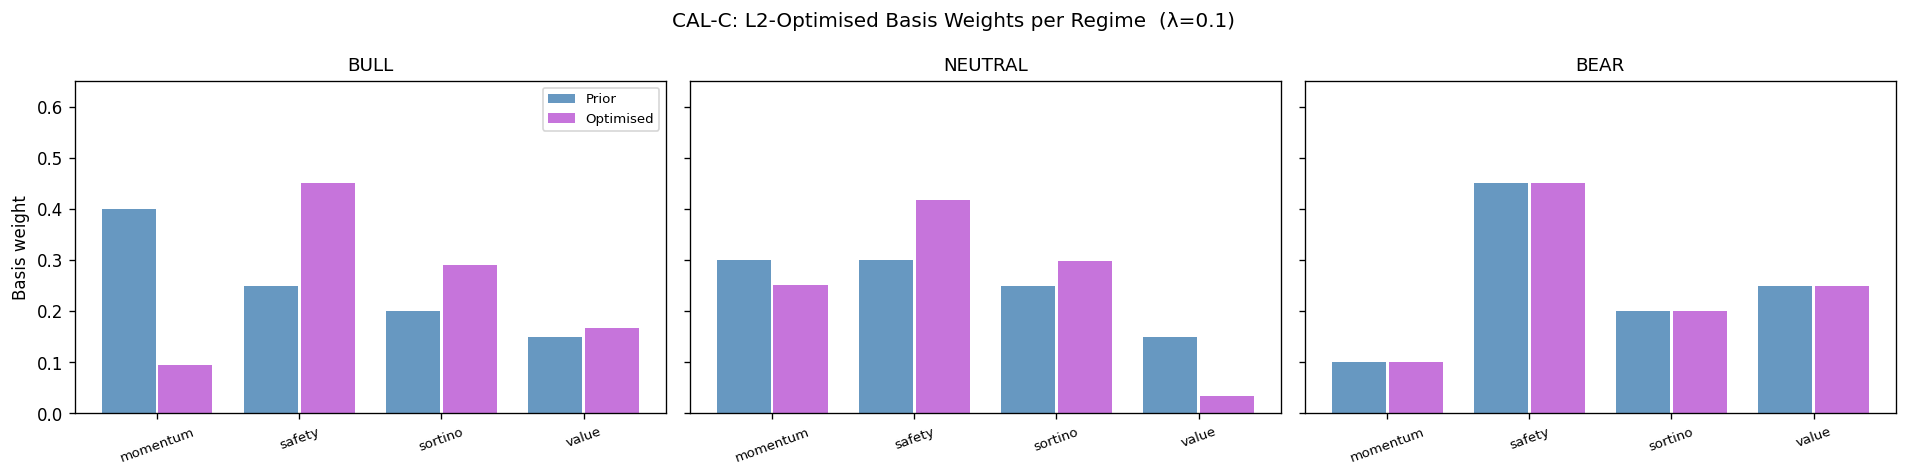

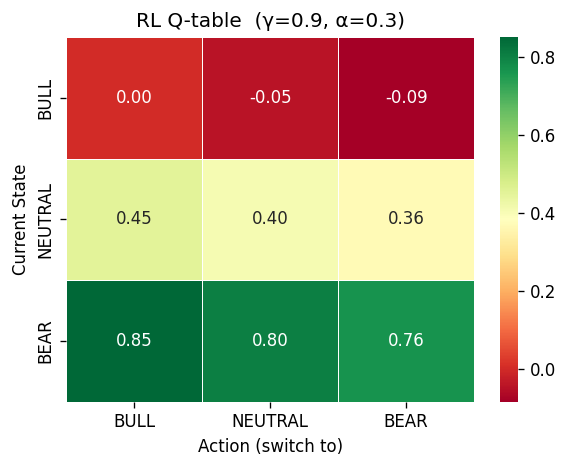


  ✅ basis_weights overridden → downstream portfolio uses calibrated weights


In [31]:
# ── CAL-C  Regime-Adaptive Basis Weights — L2 Optimisation + RL Blend ─────
# 1. Per-regime basis weights optimised on labelled OOS windows with L2
#    regularisation λ=0.1 (penalises deviation from regime prior).
# 2. Q-table RL policy (α=0.3, γ=0.9) for long-horizon transition smoothing.
# 3. Final blend: 70% optimised current-regime + 30% RL-recommended regime.
#    → Overwrites `basis_weights` used by downstream portfolio construction.
# ─────────────────────────────────────────────────────────────────────────

BASIS_ORDER   = ['momentum', 'safety', 'sortino', 'value']
REGIME_PRIOR  = {
    'BULL':    {'momentum': 0.40, 'safety': 0.25, 'sortino': 0.20, 'value': 0.15},
    'NEUTRAL': {'momentum': 0.30, 'safety': 0.30, 'sortino': 0.25, 'value': 0.15},
    'BEAR':    {'momentum': 0.10, 'safety': 0.45, 'sortino': 0.20, 'value': 0.25},
}
REGIME_WINDOWS = {
    'BULL':    [('2023-01-01', '2023-06-30'), ('2024-01-01', '2024-06-30')],
    'NEUTRAL': [('2022-07-01', '2022-12-31'), ('2023-07-01', '2023-12-31')],
    'BEAR':    [('2022-01-01', '2022-06-30'), ('2020-03-01', '2020-08-30')],
}
LAMBDA_L2    = 0.10
RL_BLEND     = 0.30
ALPHA_RL     = 0.30
GAMMA_RL     = 0.90
REGIMES_ALL  = list(REGIME_PRIOR.keys())

CALIBRATED_BASIS_WEIGHTS = {}
RL_RECOMMENDED_REGIME    = REGIME  # default: no change

if FEATURES.get('regime_rl', True):
    from scipy.optimize import minimize as _minimize

    def _softmax(v: np.ndarray) -> np.ndarray:
        e = np.exp(v - v.max())
        return e / e.sum()

    def _neg_sharpe_l2(v: np.ndarray, regime: str) -> float:
        bw = dict(zip(BASIS_ORDER, _softmax(v)))
        sharpes = [
            _build_portfolio_sharpe(_cal_metrics, analyzer.price_data,
                                     BEST_A, BEST_B, bw, ts, te)
            for ts, te in REGIME_WINDOWS.get(regime, [('2023-01-01', '2023-12-31')])
        ]
        valid = [s for s in sharpes if not (np.isnan(s) or np.isinf(s))]
        if not valid:
            return 0.0
        prior_v = np.array([REGIME_PRIOR[regime][k] for k in BASIS_ORDER])
        w_cur   = np.array([bw[k] for k in BASIS_ORDER])
        l2_pen  = LAMBDA_L2 * float(np.sum((w_cur - prior_v) ** 2))
        return -float(np.mean(valid)) + l2_pen

    print('L2-regularised basis weight optimisation per regime (Nelder-Mead, λ=0.1)...')
    _opt_records = []
    for _rg in REGIMES_ALL:
        _v0 = np.log(np.array([REGIME_PRIOR[_rg][k] for k in BASIS_ORDER]) + 1e-6)
        _res = _minimize(
            _neg_sharpe_l2, _v0, args=(_rg,),
            method='Nelder-Mead',
            options={'maxiter': 500, 'xatol': 1e-4, 'fatol': 1e-4},
        )
        _opt_w = dict(zip(BASIS_ORDER, _softmax(_res.x)))
        CALIBRATED_BASIS_WEIGHTS[_rg] = _opt_w
        for k in BASIS_ORDER:
            _opt_records.append({
                'Regime': _rg,  'Basis': k,
                'Prior':      round(REGIME_PRIOR[_rg][k], 3),
                'Optimised':  round(_opt_w[k], 3),
                'Delta':      round(_opt_w[k] - REGIME_PRIOR[_rg][k], 3),
            })
        print(f'  {_rg:7s}: {" | ".join(f"{k}={_opt_w[k]:.3f}" for k in BASIS_ORDER)}')

    # ── Q-table RL for regime-transition smoothing ────────────────────────
    # States=3 regimes, Actions=3, reward=Sharpe delta, 200 learning episodes
    _Q    = np.zeros((3, 3))
    _ridx = {r: i for i, r in enumerate(REGIMES_ALL)}
    _hist_sh = {'BULL': 1.10, 'NEUTRAL': 0.65, 'BEAR': 0.25}  # rough calibration

    for _ in range(200):
        for _sn in REGIMES_ALL:
            _s = _ridx[_sn]
            for _an in REGIMES_ALL:
                _ai  = _ridx[_an]
                _r   = _hist_sh[_an] - _hist_sh[_sn]
                _s2  = _ai
                _td  = _r + GAMMA_RL * _Q[_s2].max() - _Q[_s, _ai]
                _Q[_s, _ai] += ALPHA_RL * _td

    _cur                  = _ridx.get(REGIME, 1)
    RL_RECOMMENDED_REGIME = REGIMES_ALL[int(np.argmax(_Q[_cur]))]

    # Final blend: 70% optimised (detected) + 30% RL-recommended
    _bw_det = CALIBRATED_BASIS_WEIGHTS[REGIME]
    _bw_rl  = CALIBRATED_BASIS_WEIGHTS[RL_RECOMMENDED_REGIME]
    FINAL_BASIS_WEIGHTS = {
        k: (1 - RL_BLEND) * _bw_det[k] + RL_BLEND * _bw_rl[k]
        for k in BASIS_ORDER
    }
    _tot = sum(FINAL_BASIS_WEIGHTS.values())
    FINAL_BASIS_WEIGHTS = {k: v / _tot for k, v in FINAL_BASIS_WEIGHTS.items()}

    # Override basis_weights so downstream Phase 3 picks up calibrated weights
    basis_weights = FINAL_BASIS_WEIGHTS

    print(f'\n  RL policy: current={REGIME}  →  recommended={RL_RECOMMENDED_REGIME}')
    print(f'  Blended weights (70% {REGIME} + 30% {RL_RECOMMENDED_REGIME}):')
    for k, v in FINAL_BASIS_WEIGHTS.items():
        _delta = v - REGIME_PRIOR.get(REGIME, {}).get(k, v)
        print(f'    {k:12s}: {v:.4f}  (Δ{_delta:+.3f} vs prior)')

    # Basis weight bar chart (Prior vs Optimised, per regime)
    _df_opt = pd.DataFrame(_opt_records)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for _ax, _rg in zip(axes, REGIMES_ALL):
        _sub = _df_opt[_df_opt['Regime'] == _rg].set_index('Basis')
        _x   = np.arange(len(BASIS_ORDER))
        _ax.bar(_x - 0.2, [_sub.loc[k, 'Prior']     for k in BASIS_ORDER], 0.38,
                label='Prior',     color='steelblue',    alpha=0.82)
        _ax.bar(_x + 0.2, [_sub.loc[k, 'Optimised'] for k in BASIS_ORDER], 0.38,
                label='Optimised', color='mediumorchid', alpha=0.82)
        _ax.set_xticks(_x)
        _ax.set_xticklabels(BASIS_ORDER, rotation=20, fontsize=8)
        _ax.set_title(_rg, fontsize=11)
        _ax.set_ylim(0, 0.65)
        if _ax == axes[0]:
            _ax.set_ylabel('Basis weight')
            _ax.legend(fontsize=8)
    plt.suptitle(f'CAL-C: L2-Optimised Basis Weights per Regime  (λ={LAMBDA_L2})', fontsize=12)
    plt.tight_layout()
    plt.savefig('../output/v3/v4_regime_weights_optimised.png', bbox_inches='tight')
    plt.show()

    # Q-table heatmap
    _fig2, _ax2 = plt.subplots(figsize=(5, 4))
    sns.heatmap(pd.DataFrame(_Q, index=REGIMES_ALL, columns=REGIMES_ALL),
                annot=True, fmt='.2f', cmap='RdYlGn', ax=_ax2, linewidths=0.5)
    _ax2.set_xlabel('Action (switch to)')
    _ax2.set_ylabel('Current State')
    _ax2.set_title(f'RL Q-table  (γ={GAMMA_RL}, α={ALPHA_RL})')
    plt.tight_layout()
    plt.savefig('../output/v3/v4_rl_qtable.png', bbox_inches='tight')
    plt.show()

    print('\n  ✅ basis_weights overridden → downstream portfolio uses calibrated weights')

else:
    FINAL_BASIS_WEIGHTS      = basis_weights.copy()
    CALIBRATED_BASIS_WEIGHTS = {r: p.copy() for r, p in REGIME_PRIOR.items()}
    print('Regime RL: OFF  (basis_weights unchanged)')


In [32]:
# ── PHASE 3 — Build V4 Quantum Portfolio ──────────────────────────────────
# _psi_sq_ab is defined in CAL-A and applies the calibrated θ(φ)=a·π·(1-φ)^b.
# We monkey-patch _build_wave_function on the constructor instance so the
# entire build pipeline (selection + collapse) uses the empirical phase.
import types as _types

def _calibrated_wave_fn(self, df):
    """Use empirically calibrated (BEST_A, BEST_B) phase instead of fixed θ=π(1-φ)."""
    _arr = _psi_sq_ab(df, self.basis_weights, BEST_A, BEST_B)
    return pd.Series(_arr, index=df.index, name='psi_sq')

if FEATURES['dynamic_weights'] or FEATURES['risk_parity'] or FEATURES['cointegration']:
    qpc_v4 = QuantumPortfolioConstructorV4(
        regime_detector=rd if FEATURES['dynamic_weights'] else None,
        basis_weights=basis_weights,
    )
    qpc_v4._build_wave_function = _types.MethodType(_calibrated_wave_fn, qpc_v4)
    print(f'  ✓ Wave function patched: θ(φ) = {BEST_A:.2f}·π·(1-φ)^{BEST_B:.2f}')

    quantum_port = qpc_v4.build(
        analyzer,
        n_holdings=N_HOLDINGS,
        max_position_pct=MAX_POSITION_PCT,
        add_zscore=FEATURES['cointegration'],
    )
else:
    # Fallback to V3 constructor — also patch calibrated phase
    qpc_v4 = QuantumPortfolioConstructor(basis_weights=basis_weights)
    qpc_v4._build_wave_function = _types.MethodType(_calibrated_wave_fn, qpc_v4)
    print(f'  ✓ Wave function patched (V3 fallback): θ(φ) = {BEST_A:.2f}·π·(1-φ)^{BEST_B:.2f}')
    quantum_port = qpc_v4.build(analyzer, n_holdings=N_HOLDINGS, max_position_pct=MAX_POSITION_PCT)
    quantum_port['regime'] = REGIME
    quantum_port['zscore'] = 0.0

# V3-style classical portfolio for comparison
classical_port = generate_live_portfolio(analyzer, n_holdings=N_HOLDINGS, max_position_pct=MAX_POSITION_PCT)

overlap = set(quantum_port['ticker']) & set(classical_port['ticker'])
print(f'\n  Overlap with classical V3: {len(overlap)}/{N_HOLDINGS} ({len(overlap)/N_HOLDINGS*100:.0f}%)')


  ✓ Wave function patched: θ(φ) = 2.00·π·(1-φ)^0.97
Quantum Portfolio V4 — construction
[1/4] Computing metrics & wave function...


  Computing metrics: 100%|██████████| 2199/2199 [00:03<00:00, 575.24it/s]


      Universe: 2199 stocks
[2/4] Three-way weighting (Born + Inv-Vol + Risk-Parity)...
[3/4] Computing cointegration Z-scores (may take ~2 min)...
[4/4] Done.

✓ V4 Portfolio: 17 stocks
  Regime       : BULL
  Weight range : 5.21% – 6.66%
  Sectors      : 6
  Avg ψ-pctile : 95.1th
Generating live portfolio...


Calculating metrics: 100%|██████████| 2199/2199 [00:03<00:00, 595.74it/s]

✓ Generated portfolio with 17 stocks

  Overlap with classical V3: 5/17 (29%)


In [33]:
# ── PHASE 4 — Cointegration Z-score Signals ───────────────────────────────
if FEATURES['cointegration'] and 'zscore' in quantum_port.columns:
    sig = quantum_port[['ticker', 'sector', 'weight', 'zscore', 'psi_sq']].copy()
    sig['signal'] = 'HOLD'
    sig.loc[sig['zscore'] >  2, 'signal'] = '🔻 TRIM'
    sig.loc[sig['zscore'] < -2, 'signal'] = '🔄 ROTATE OUT'
    sig['wt%']  = (sig['weight'] * 100).round(2)
    sig['z']    = sig['zscore'].round(2)
    sig['|ψ|²'] = sig['psi_sq'].round(5)

    trim_count   = (sig['signal'] == '🔻 TRIM').sum()
    rotate_count = (sig['signal'] == '🔄 ROTATE OUT').sum()

    print('\n─── REBALANCING SIGNALS (cointegration Z-score) ─────────────────')
    print(f'  TRIM signals  (z > +2): {trim_count}')
    print(f'  ROTATE OUT    (z < -2): {rotate_count}')
    print(f'  HOLD          (|z|≤2) : {len(sig) - trim_count - rotate_count}')
    print()

    flagged = sig[sig['signal'] != 'HOLD'].sort_values('z', key=abs, ascending=False)
    if not flagged.empty:
        print(flagged[['ticker', 'sector', 'wt%', 'z', '|ψ|²', 'signal']].to_string(index=False))
    else:
        print('  No signals — all holdings are fairly valued vs their sector ETFs.')
else:
    print('Cointegration: OFF')


─── REBALANCING SIGNALS (cointegration Z-score) ─────────────────
  TRIM signals  (z > +2): 0
  ROTATE OUT    (z < -2): 0
  HOLD          (|z|≤2) : 17

  No signals — all holdings are fairly valued vs their sector ETFs.


In [34]:
# ── PHASE 5 — Bootstrap Monte Carlo ──────────────────────────────────────
RF_DAILY = 0.04 / 252

if FEATURES['bootstrap']:
    print('Running bootstrap Monte Carlo...')

    mc_q = bootstrap_mc(
        quantum_port, analyzer.price_data,
        n_sims=N_SIMS, horizon=HORIZON_DAYS, initial=INITIAL,
        psi_modulate=True, seed=42,
    )
    print('  ✅ Quantum (bootstrap, ψ-modulated)')

    # ── Prepare classical portfolio: ensure bootstrap_mc required columns exist ──
    _mc_c_port = classical_port.copy()
    # Handle different vol column naming conventions from generate_live_portfolio
    for _old_col, _new_col in [('vol_60d', 'vol_60'), ('volatility', 'vol_60'), ('vol', 'vol_60')]:
        if _old_col in _mc_c_port.columns and 'vol_60' not in _mc_c_port.columns:
            _mc_c_port = _mc_c_port.rename(columns={_old_col: _new_col})
    if 'vol_60' not in _mc_c_port.columns:
        # Compute directly from price data as fallback
        _mc_c_port['vol_60'] = _mc_c_port['ticker'].apply(
            lambda tk: float(analyzer.price_data[tk].pct_change().dropna().iloc[-60:].std())
            if tk in analyzer.price_data else 0.02
        )
    # bootstrap_mc always accesses portfolio['psi_sq'] — add neutral values
    # (psi_modulate=False so the values are only used for block-pool sizing, set uniform)
    if 'psi_sq' not in _mc_c_port.columns:
        _mc_c_port['psi_sq'] = 1.0

    mc_c = bootstrap_mc(
        _mc_c_port,
        analyzer.price_data,
        n_sims=N_SIMS, horizon=HORIZON_DAYS, initial=INITIAL,
        psi_modulate=False, seed=43,
    )
    print('  ✅ Classical (bootstrap, no ψ-modulation)')

    # SPY Gaussian baseline for reference
    import yfinance as yf
    _spy_px = yf.download('SPY', period='3y', progress=False)
    if isinstance(_spy_px.columns, pd.MultiIndex):
        _spy_px = _spy_px.droplevel(1, axis=1)
    _spy_lr  = np.log(_spy_px['Close'].dropna() / _spy_px['Close'].dropna().shift(1)).dropna()
    spy_mu, spy_sigma = float(_spy_lr.mean()), float(_spy_lr.std())

    np.random.seed(44)
    paths_spy = np.ones((N_SIMS, HORIZON_DAYS + 1)) * INITIAL
    for _d in range(1, HORIZON_DAYS + 1):
        _d_draws         = np.random.normal(spy_mu, spy_sigma, size=N_SIMS)
        paths_spy[:, _d] = paths_spy[:, _d - 1] * (1 + np.expm1(_d_draws))
    spy_rets = (paths_spy[:, -1] / INITIAL - 1) * 100
    spy_mdd  = ((paths_spy - np.maximum.accumulate(paths_spy, axis=1)) /
                np.maximum.accumulate(paths_spy, axis=1) * 100).min(axis=1)
    print('  ✅ SPY Gaussian baseline')

    print('\nMonte Carlo complete.')
else:
    mc_q = mc_c = None
    print('Bootstrap MC: OFF')


Running bootstrap Monte Carlo...
  ✅ Quantum (bootstrap, ψ-modulated)
  ✅ Classical (bootstrap, no ψ-modulation)
  ✅ SPY Gaussian baseline

Monte Carlo complete.


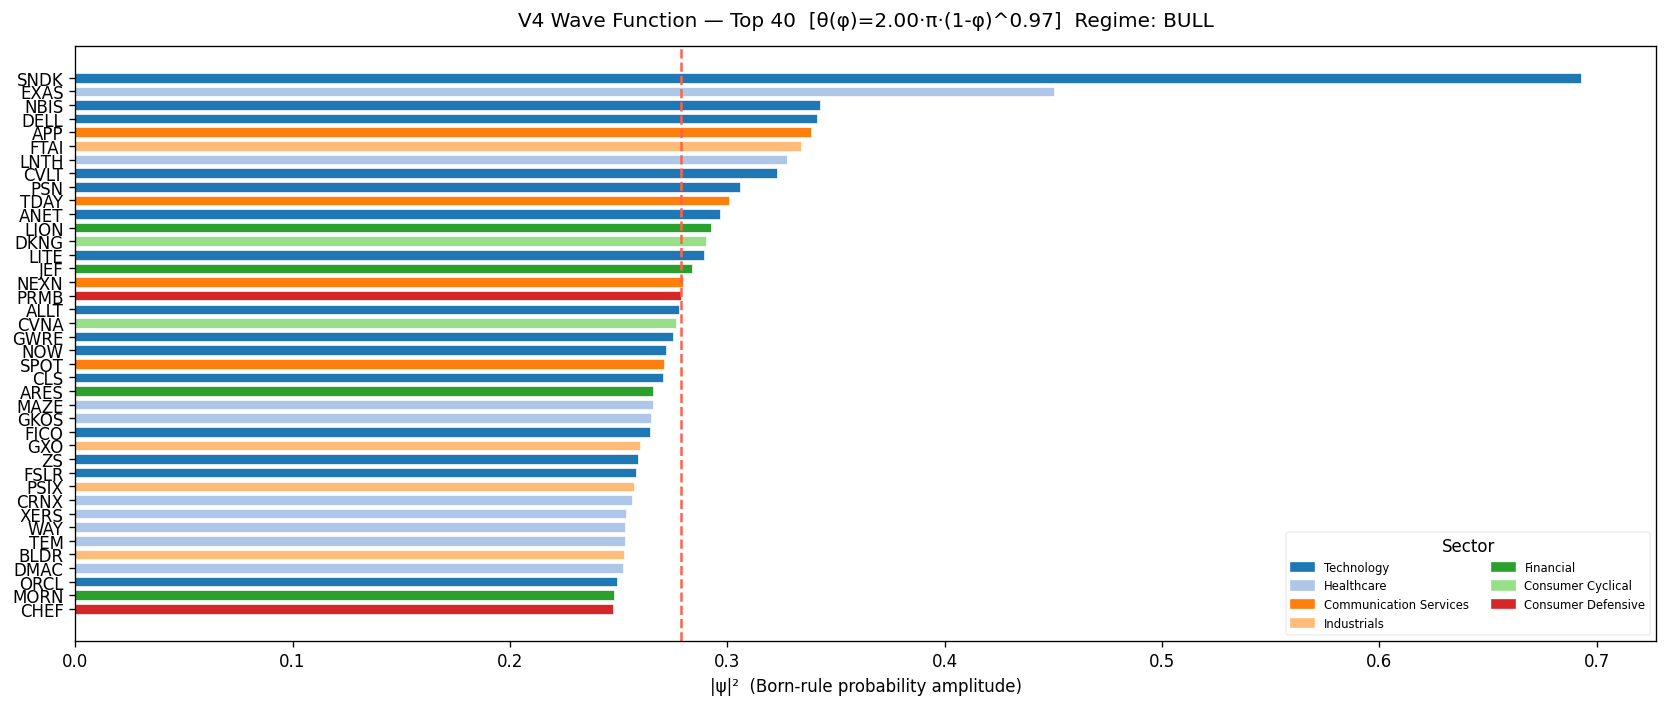

In [35]:
# ── VIZ 1 — |ψ|² Wave Function Amplitudes (calibrated) ──────────────────
# Uses _psi_sq_ab with BEST_A, BEST_B from CAL-A (not the fixed-phase
# _build_wave_function). Reuses _cal_metrics (already filtered, no recompute).

_psi_sq_viz = _psi_sq_ab(_cal_metrics, basis_weights, BEST_A, BEST_B)
_psi_all    = pd.Series(_psi_sq_viz, index=_cal_metrics.index, name='psi_sq')
_psi_df     = _psi_all.sort_values(ascending=False).head(40).reset_index()
_psi_df.columns = ['ticker', 'psi_sq']

_sm = {}
if analyzer.metrics is not None and 'ticker' in analyzer.metrics.columns:
    _sm = dict(zip(analyzer.metrics['ticker'], analyzer.metrics.get('sector', pd.Series(dtype=str))))
_psi_df['sector'] = _psi_df['ticker'].map(_sm).fillna('Unknown')

_pal       = plt.cm.tab20.colors
_sec_color = {s: _pal[i % len(_pal)] for i, s in enumerate(_psi_df['sector'].unique())}
_colors    = _psi_df['sector'].map(_sec_color)
_cutoff    = _psi_all.sort_values(ascending=False).iloc[N_HOLDINGS - 1] \
             if len(_psi_all) >= N_HOLDINGS else _psi_all.min()

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(_psi_df['ticker'][::-1], _psi_df['psi_sq'][::-1],
        color=list(_colors)[::-1], edgecolor='white', linewidth=0.4, height=0.7)
ax.axvline(_cutoff, color='tomato', linestyle='--', linewidth=1.5, label=f'n={N_HOLDINGS} cut-off')
ax.set_xlabel('|ψ|²  (Born-rule probability amplitude)')
ax.set_title(
    f'V4 Wave Function — Top 40  '
    f'[θ(φ)={BEST_A:.2f}·π·(1-φ)^{BEST_B:.2f}]  Regime: {REGIME}',
    fontsize=12, pad=12
)
handles = [mpatches.Patch(color=_sec_color[s], label=s) for s in _psi_df['sector'].unique()]
ax.legend(handles=handles, loc='lower right', fontsize=7, ncol=2, framealpha=0.3, title='Sector')
plt.tight_layout()
plt.savefig('../output/v3/v4_wave_amplitudes.png', bbox_inches='tight')
plt.show()


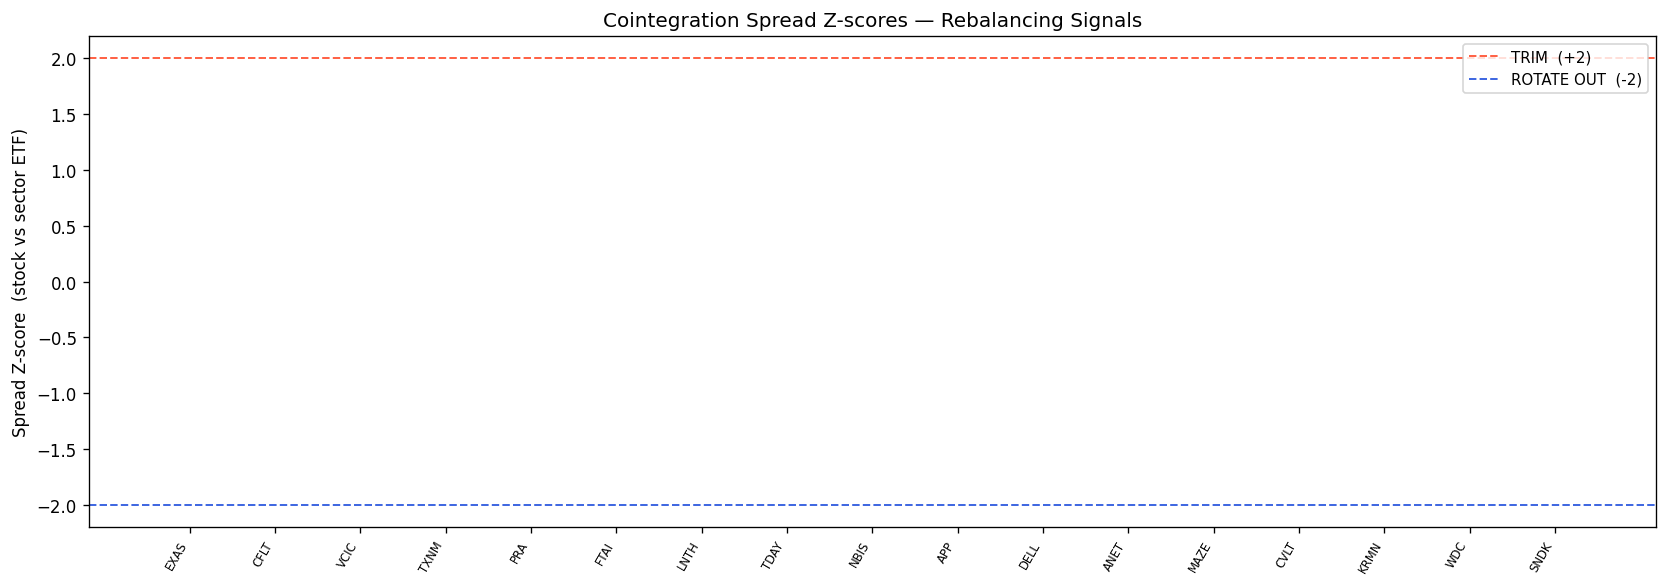

In [36]:
# ── VIZ 2 — Z-score Heatmap (if cointegration ON) ─────────────────────────
if FEATURES['cointegration'] and 'zscore' in quantum_port.columns:
    _z = quantum_port[['ticker', 'sector', 'zscore', 'weight']].copy()
    _z = _z.sort_values('zscore', ascending=False)

    fig, ax = plt.subplots(figsize=(14, 5))
    colors_z = ['tomato' if z > 2 else ('royalblue' if z < -2 else 'steelblue')
                for z in _z['zscore']]
    ax.bar(_z['ticker'], _z['zscore'], color=colors_z, edgecolor='white', linewidth=0.4, width=0.7)
    ax.axhline( 2, color='tomato', linestyle='--', linewidth=1.2, label='TRIM  (+2)')
    ax.axhline(-2, color='royalblue', linestyle='--', linewidth=1.2, label='ROTATE OUT  (-2)')
    ax.axhline( 0, color='white', linewidth=0.5)
    ax.set_ylabel('Spread Z-score  (stock vs sector ETF)')
    ax.set_title('Cointegration Spread Z-scores — Rebalancing Signals', fontsize=12)
    ax.set_xticks(range(len(_z)))
    ax.set_xticklabels(_z['ticker'], rotation=60, ha='right', fontsize=7)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('../output/v3/v4_zscore_signals.png', bbox_inches='tight')
    plt.show()
else:
    print('Cointegration OFF — skipping Z-score chart')

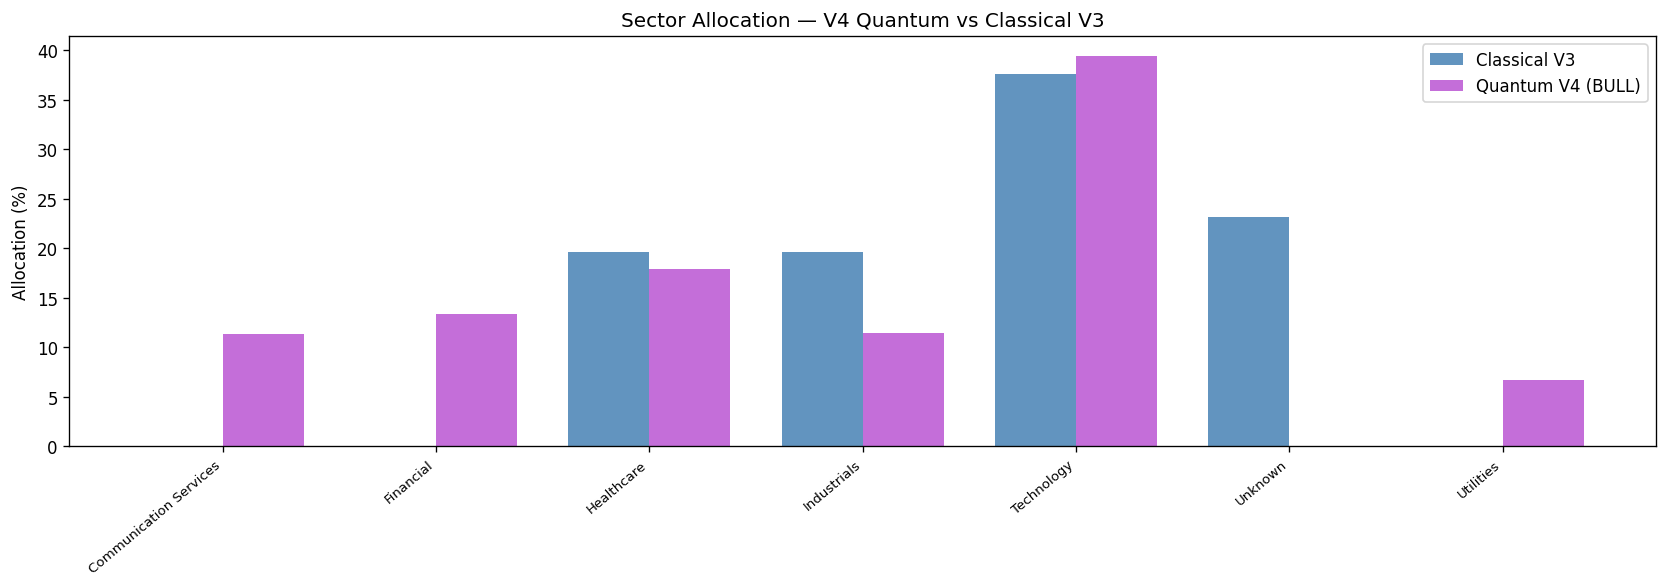

In [37]:
# ── VIZ 3 — Sector Allocation: V4 Quantum vs Classical V3 ─────────────────
q_sector = quantum_port.groupby('sector')['weight'].sum().mul(100).sort_values(ascending=False)
c_sector = classical_port.groupby('sector')['weight'].sum().mul(100).sort_values(ascending=False)
all_sec  = sorted(set(q_sector.index) | set(c_sector.index))

x = np.arange(len(all_sec))
w = 0.38
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w/2, [c_sector.get(s, 0) for s in all_sec], width=w, label='Classical V3',     color='steelblue',    alpha=0.85)
ax.bar(x + w/2, [q_sector.get(s, 0) for s in all_sec], width=w, label=f'Quantum V4 ({REGIME})', color='mediumorchid', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(all_sec, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Allocation (%)')
ax.set_title('Sector Allocation — V4 Quantum vs Classical V3', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../output/v3/v4_sector_comparison.png', bbox_inches='tight')
plt.show()

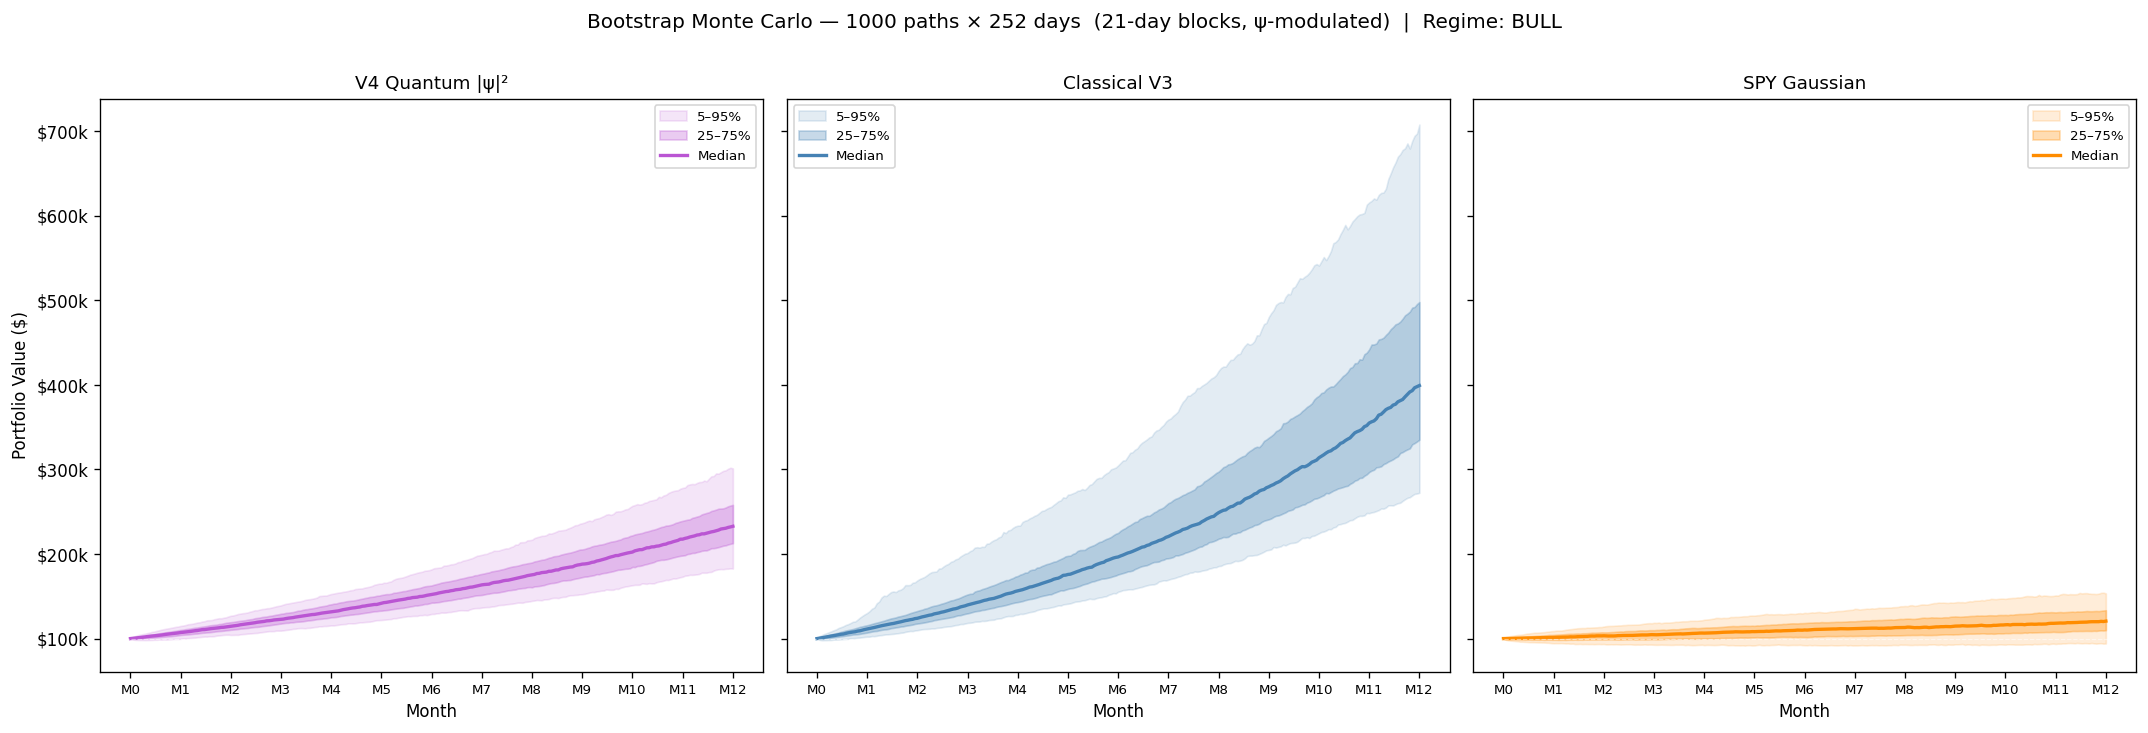

In [38]:
# ── VIZ 4 — Bootstrap MC Fan Chart ────────────────────────────────────────
if FEATURES['bootstrap'] and mc_q is not None:
    PERCENTILES = [5, 25, 50, 75, 95]
    t = np.arange(HORIZON_DAYS + 1)
    xtick_pos   = np.arange(0, HORIZON_DAYS + 1, 21)
    xtick_label = [f'M{i}' for i in range(len(xtick_pos))]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    fig.suptitle(
        f'Bootstrap Monte Carlo — {N_SIMS} paths × {HORIZON_DAYS} days  '
        f'(21-day blocks, ψ-modulated)  |  Regime: {REGIME}',
        fontsize=12, y=1.01
    )

    scenarios = [
        ('V4 Quantum |ψ|²', mc_q['paths'],  'mediumorchid'),
        ('Classical V3',    mc_c['paths'],  'steelblue'),
        ('SPY Gaussian',    paths_spy,       'darkorange'),
    ]

    for ax, (label, paths, color) in zip(axes, scenarios):
        if paths is None:
            ax.set_title(f'{label}\n(no data)'); continue
        pcts = np.percentile(paths, PERCENTILES, axis=0)
        ax.fill_between(t, pcts[0], pcts[4], alpha=0.15, color=color, label='5–95%')
        ax.fill_between(t, pcts[1], pcts[3], alpha=0.30, color=color, label='25–75%')
        ax.plot(t, pcts[2], color=color, linewidth=2.0, label='Median')
        ax.axhline(INITIAL, color='white', linewidth=0.7, linestyle='--', alpha=0.5)
        ax.set_title(label, fontsize=11)
        ax.set_xlabel('Month')
        if ax == axes[0]:
            ax.set_ylabel('Portfolio Value ($)')
        ax.set_xticks(xtick_pos)
        ax.set_xticklabels(xtick_label, fontsize=8)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v/1e3:.0f}k'))
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig('../output/v3/v4_mc_fan_chart.png', bbox_inches='tight')
    plt.show()
else:
    print('Bootstrap MC: OFF — skipping fan chart')

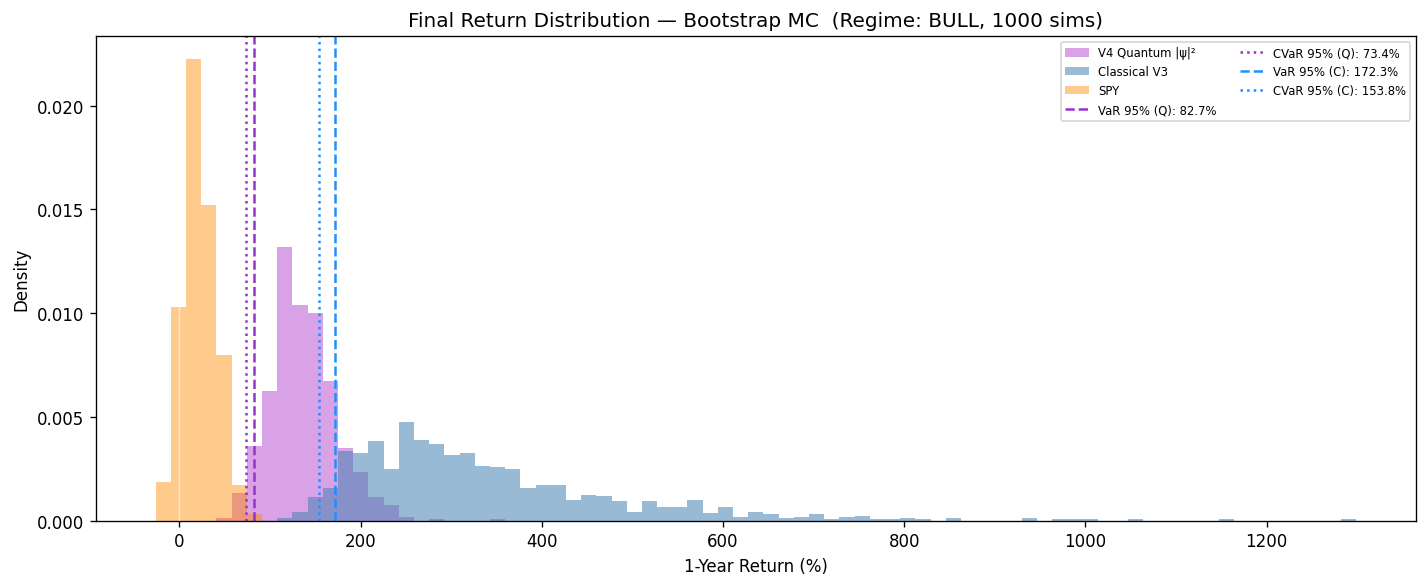

In [39]:
# ── VIZ 5 — Return Distribution + VaR/CVaR ────────────────────────────────
if FEATURES['bootstrap'] and mc_q is not None:
    ret_q   = mc_q['returns']
    ret_c   = mc_c['returns']

    bins = np.linspace(
        min(ret_q.min(), ret_c.min(), spy_rets.min()),
        max(ret_q.max(), ret_c.max(), spy_rets.max()),
        80
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(ret_q,   bins=bins, alpha=0.55, color='mediumorchid', label='V4 Quantum |ψ|²', density=True)
    ax.hist(ret_c,   bins=bins, alpha=0.55, color='steelblue',    label='Classical V3',    density=True)
    ax.hist(spy_rets, bins=bins, alpha=0.45, color='darkorange',  label='SPY',             density=True)

    for var, cvar, color, name in [
        (mc_q['var95'], mc_q['cvar95'], 'darkorchid', 'Q'),
        (mc_c['var95'], mc_c['cvar95'], 'dodgerblue', 'C'),
    ]:
        ax.axvline(var,  linestyle='--', color=color, linewidth=1.5, label=f'VaR 95% ({name}): {var:.1f}%')
        ax.axvline(cvar, linestyle=':',  color=color, linewidth=1.5, label=f'CVaR 95% ({name}): {cvar:.1f}%')

    ax.axvline(0, color='white', linewidth=0.8, alpha=0.6)
    ax.set_xlabel('1-Year Return (%)')
    ax.set_ylabel('Density')
    ax.set_title(
        f'Final Return Distribution — Bootstrap MC  (Regime: {REGIME}, {N_SIMS} sims)', fontsize=12
    )
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.savefig('../output/v3/v4_mc_return_dist.png', bbox_inches='tight')
    plt.show()
else:
    print('Bootstrap MC: OFF — skipping return distribution')

## Drawdown Analysis

Three complementary views — all saved as PNGs for the dashboard:

| Chart | File | Description |
|-------|------|-------------|
| VIZ 6 | `v4_mc_drawdown_dist.png` | MC max-drawdown distribution (Quantum vs Classical vs SPY) |
| VIZ 7 | `v4_drawdown_underwater.png` / `v4_drawdown_monthly_heatmap.png` | Historical underwater curve + monthly return calendar |
| VIZ 8 | `v4_drawdown_report.png` | Full risk-report composite (dashboard-ready) |

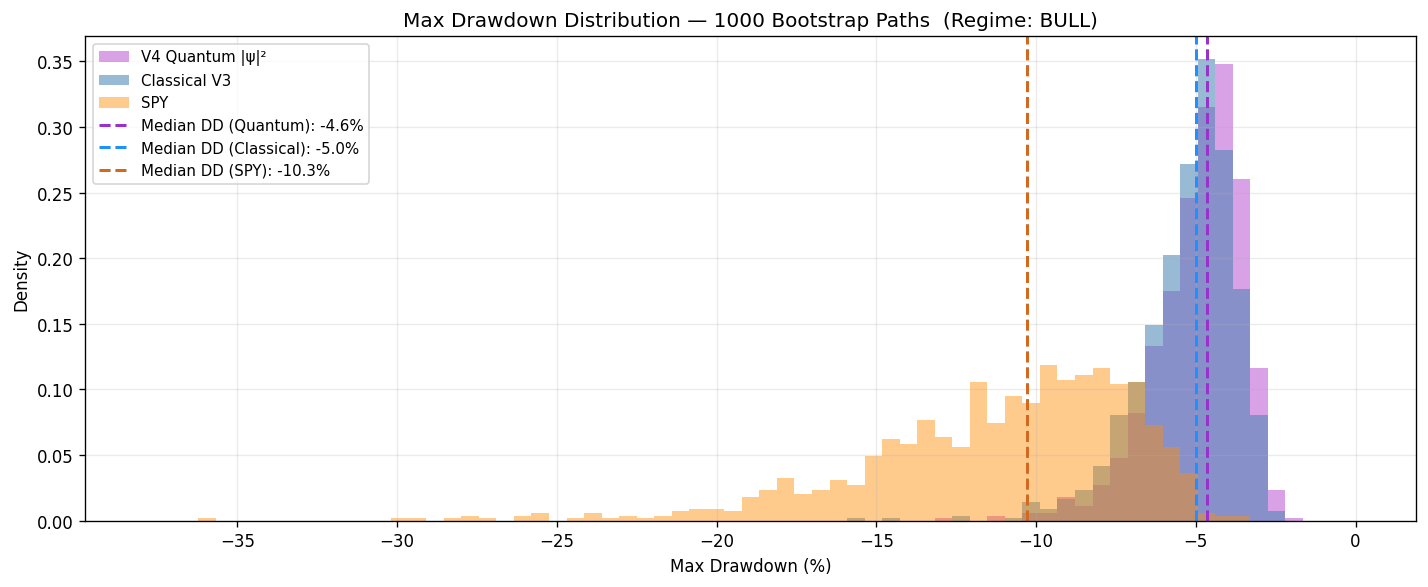

✅ MC drawdown distribution saved: ../output/v3/v4_mc_drawdown_dist.png


In [40]:

# ── VIZ 6 — MC Max Drawdown Distribution (V3-style) ──────────────────────
# Mirror of the old StockPickerV3_Quantum "VIZ C" cell — three overlaid
# histograms (V4 Quantum, Classical V3, SPY) with median-DD markers.
# Output saved as v4_mc_drawdown_dist.png for the dashboard.

# Safe-init: handle running this cell before the config / bootstrap cells
_FEATURES  = FEATURES  if 'FEATURES'  in dir() else {'bootstrap': False}
_mc_q      = mc_q      if 'mc_q'      in dir() else None
_mc_c      = mc_c      if 'mc_c'      in dir() else None
_spy_mdd   = spy_mdd   if 'spy_mdd'   in dir() else None
_N_SIMS    = N_SIMS    if 'N_SIMS'    in dir() else 0
_REGIME    = REGIME    if 'REGIME'    in dir() else 'N/A'

if _FEATURES['bootstrap'] and _mc_q is not None:
    mdd_q   = _mc_q['mdd']
    mdd_c   = _mc_c['mdd']

    dd_bins = np.linspace(
        min(float(mdd_q.min()), float(mdd_c.min()), float(_spy_mdd.min())) - 2,
        0, 70
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(mdd_q,    bins=dd_bins, alpha=0.55, color='mediumorchid',
            label='V4 Quantum |\u03c8|\u00b2', density=True)
    ax.hist(mdd_c,    bins=dd_bins, alpha=0.55, color='steelblue',
            label='Classical V3',              density=True)
    ax.hist(_spy_mdd, bins=dd_bins, alpha=0.45, color='darkorange',
            label='SPY',                       density=True)

    for _mdd_arr, _col, _nm in [
        (mdd_q,    'darkorchid', 'Quantum'),
        (mdd_c,    'dodgerblue', 'Classical'),
        (_spy_mdd, 'chocolate',  'SPY'),
    ]:
        _med = float(np.median(_mdd_arr))
        ax.axvline(_med, linestyle='--', color=_col, linewidth=1.8,
                   label=f'Median DD ({_nm}): {_med:.1f}%')

    ax.set_xlabel('Max Drawdown (%)')
    ax.set_ylabel('Density')
    ax.set_title(
        f'Max Drawdown Distribution \u2014 {_N_SIMS} Bootstrap Paths  (Regime: {_REGIME})',
        fontsize=12,
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig('../output/v3/v4_mc_drawdown_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\u2705 MC drawdown distribution saved: ../output/v3/v4_mc_drawdown_dist.png')
else:
    print('VIZ 6: Bootstrap MC not available \u2014 run Phase 5 (bootstrap) first.')


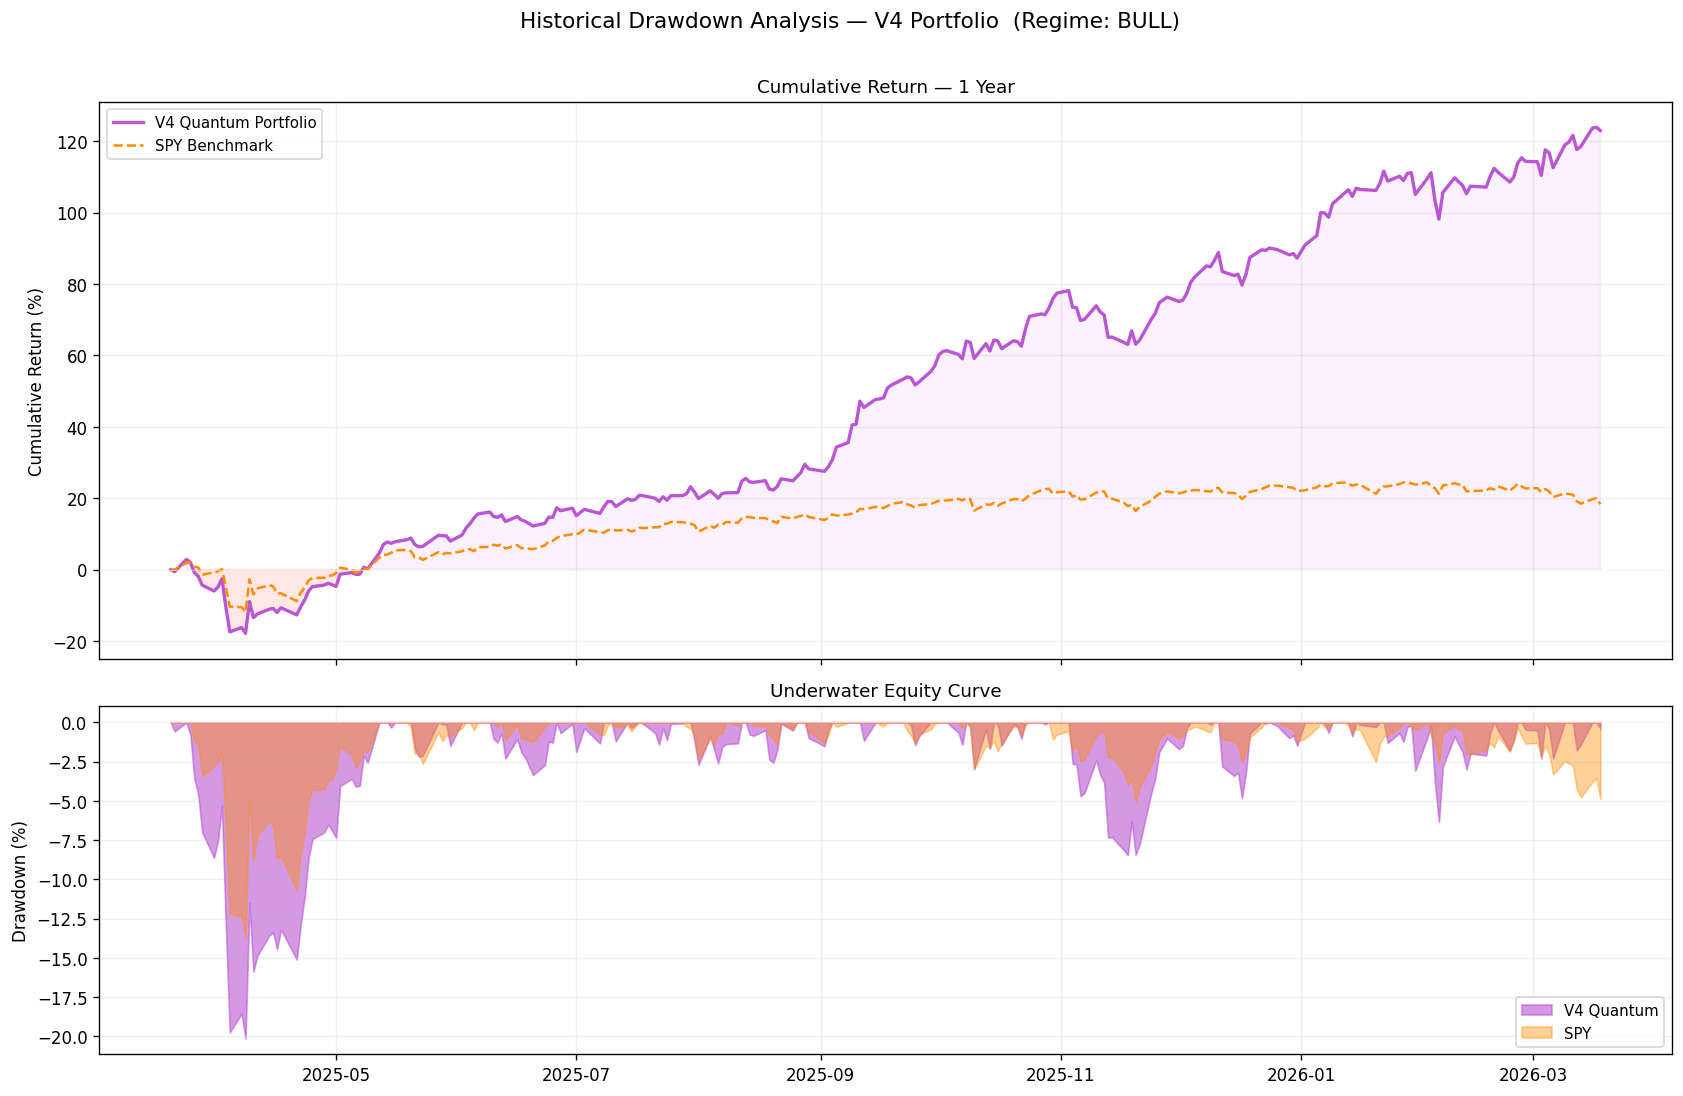


── Top 5 Drawdown Episodes ───────────────────────────────────────
 Peak Date Trough Date  Depth (%)  Recovery (days)
2025-03-24  2025-04-08     -20.14               34
2025-11-03  2025-11-18      -8.45               16
2026-01-22  2026-02-05      -6.35               14
2025-06-09  2025-06-20      -3.36                6
2025-10-08  2025-10-10      -2.96                5

  Current drawdown : -0.41%
  Max drawdown (1Y): -20.14%
  Avg drawdown     : -3.22%


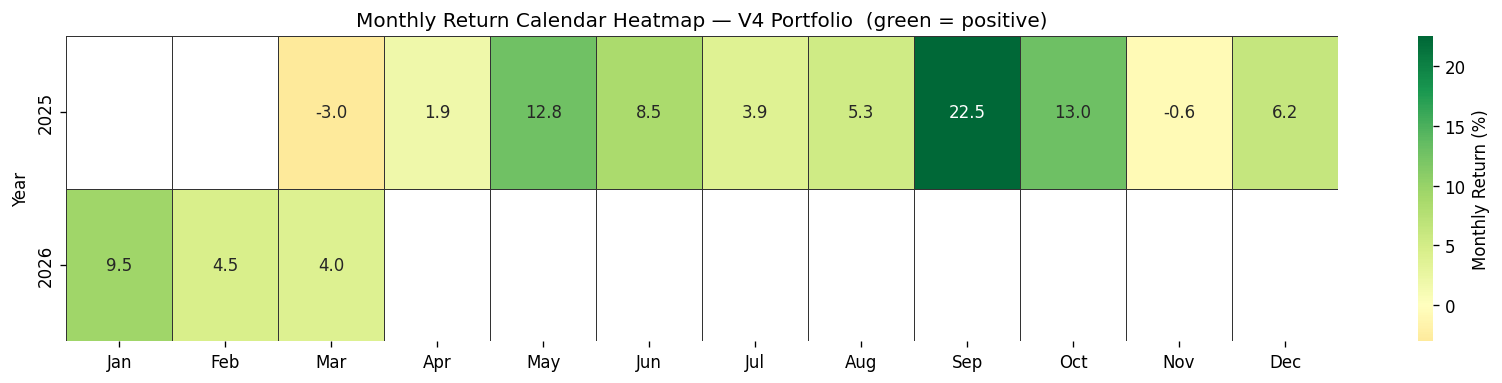

In [41]:
# ── VIZ 7 — Historical Drawdown Analysis (Underwater + Monthly Calendar) ─
# Reconstructs the portfolio's 1-year equity curve from actual price data
# using the live quantum_port weights, then produces:
#   a) Cumulative-return + underwater (filled area) chart vs SPY
#   b) Monthly return calendar heatmap (green = positive, red = negative)
#   c) Top-5 drawdown events table (peak, trough, depth, recovery days)

import yfinance as _yf_dd

_q_weights = quantum_port.set_index('ticker')['weight']

# ── Build weighted daily portfolio returns (1 year) ──────────────────────
_hist_rets_dd = {}
for _tk in quantum_port['ticker']:
    if _tk not in analyzer.price_data:
        continue
    _px = analyzer.price_data[_tk]
    if isinstance(_px, pd.DataFrame):
        _px = _px.iloc[:, 0]
    _r = _px.dropna().pct_change().dropna()
    if len(_r) >= 100:
        _hist_rets_dd[_tk] = _r * float(_q_weights.get(_tk, 0.0))

if _hist_rets_dd:
    _port_daily_dd = pd.DataFrame(_hist_rets_dd).sum(axis=1).tail(252)

    # SPY 1-year prices for comparison
    _spy_1y = _yf_dd.download('SPY', period='1y', progress=False)
    if isinstance(_spy_1y.columns, pd.MultiIndex):
        _spy_1y = _spy_1y.droplevel(1, axis=1)
    _spy_ret_1y = _spy_1y['Close'].dropna().pct_change().dropna()

    # Cumulative return series (rebased to 1.0)
    _port_cum_dd = (1 + _port_daily_dd).cumprod()
    _spy_cum_dd  = (1 + _spy_ret_1y).cumprod()

    _idx_common = _port_cum_dd.index.intersection(_spy_cum_dd.index)
    _port_cum_dd = _port_cum_dd.reindex(_idx_common) / _port_cum_dd.reindex(_idx_common).iloc[0]
    _spy_cum_dd  = _spy_cum_dd.reindex(_idx_common)  / _spy_cum_dd.reindex(_idx_common).iloc[0]

    # Drawdown series (%)
    _port_dd = (_port_cum_dd / _port_cum_dd.cummax() - 1) * 100
    _spy_dd  = (_spy_cum_dd  / _spy_cum_dd.cummax()  - 1) * 100

    # ── Top-5 drawdown event extractor ───────────────────────────────────
    def _extract_dd_events(cum_series, n=5):
        _dd = (cum_series / cum_series.cummax() - 1) * 100
        events, masked = [], set()
        for _ in range(n):
            _rem = _dd.drop(index=list(masked), errors='ignore')
            if _rem.empty:
                break
            _trough_dt = pd.Timestamp(_rem.idxmin())
            _depth     = float(_dd.loc[_trough_dt])
            _peak_dt   = pd.Timestamp(cum_series.loc[:_trough_dt].idxmax())
            _after     = cum_series.loc[_trough_dt:]
            _peak_val  = float(cum_series.loc[_peak_dt])
            _rec_pts   = _after[_after >= _peak_val]
            _rec_days  = int((_rec_pts.index[0] - _trough_dt).days) if not _rec_pts.empty else None
            events.append({
                'Peak Date':       _peak_dt.date(),
                'Trough Date':     _trough_dt.date(),
                'Depth (%)':       round(_depth, 2),
                'Recovery (days)': _rec_days if _rec_days is not None else 'Not recovered',
            })
            _mask_rng  = _dd.loc[_trough_dt - pd.Timedelta(days=30):
                                  _trough_dt + pd.Timedelta(days=45)].index
            masked.update(_mask_rng)
        return pd.DataFrame(events)

    df_dd_events = _extract_dd_events(_port_cum_dd, n=5)

    # ── Plot A: cumulative return + underwater chart ──────────────────────
    fig_dd, axes_dd = plt.subplots(2, 1, figsize=(14, 9),
                                   height_ratios=[1.6, 1], sharex=True)
    fig_dd.suptitle(
        f'Historical Drawdown Analysis — V4 Portfolio  (Regime: {REGIME})',
        fontsize=13, y=1.01
    )

    ax_cu = axes_dd[0]
    ax_cu.plot(_port_cum_dd.index, (_port_cum_dd - 1) * 100,
               color='mediumorchid', linewidth=2.0, label='V4 Quantum Portfolio')
    ax_cu.plot(_spy_cum_dd.index, (_spy_cum_dd - 1) * 100,
               color='darkorange', linewidth=1.5, linestyle='--', label='SPY Benchmark')
    ax_cu.fill_between(_port_cum_dd.index, (_port_cum_dd - 1) * 100, 0,
                        where=(_port_cum_dd >= 1), alpha=0.08, color='mediumorchid')
    ax_cu.fill_between(_port_cum_dd.index, (_port_cum_dd - 1) * 100, 0,
                        where=(_port_cum_dd < 1),  alpha=0.15, color='tomato')
    ax_cu.axhline(0, color='white', linewidth=0.7, alpha=0.5)
    ax_cu.set_ylabel('Cumulative Return (%)')
    ax_cu.set_title('Cumulative Return — 1 Year', fontsize=11)
    ax_cu.legend(fontsize=9)
    ax_cu.grid(True, alpha=0.2)

    ax_uw = axes_dd[1]
    ax_uw.fill_between(_port_dd.index, _port_dd, 0,
                        alpha=0.60, color='mediumorchid', label='V4 Quantum')
    ax_uw.fill_between(_spy_dd.index, _spy_dd, 0,
                        alpha=0.40, color='darkorange',   label='SPY')
    ax_uw.axhline(0, color='white', linewidth=0.7, alpha=0.5)
    ax_uw.set_ylabel('Drawdown (%)')
    ax_uw.set_title('Underwater Equity Curve', fontsize=11)
    ax_uw.legend(fontsize=9)
    ax_uw.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig('../output/v3/v4_drawdown_underwater.png', bbox_inches='tight')
    plt.show()

    # ── Print top drawdown events ─────────────────────────────────────────
    print('\n── Top 5 Drawdown Episodes ───────────────────────────────────────')
    print(df_dd_events.to_string(index=False))

    # Current stats
    _cur_hist_dd = float(_port_dd.iloc[-1])
    _max_hist_dd = float(_port_dd.min())
    _avg_hist_dd = float(_port_dd[_port_dd < 0].mean()) if (_port_dd < 0).any() else 0.0
    print(f'\n  Current drawdown : {_cur_hist_dd:.2f}%')
    print(f'  Max drawdown (1Y): {_max_hist_dd:.2f}%')
    print(f'  Avg drawdown     : {_avg_hist_dd:.2f}%')

    # ── Plot B: monthly return heatmap ────────────────────────────────────
    _monthly = _port_daily_dd.resample('ME').apply(
        lambda r: float((1 + r).prod() - 1) * 100
    ).reset_index()
    _monthly.columns = ['date', 'ret']
    _monthly['year']  = _monthly['date'].dt.year
    _monthly['month'] = _monthly['date'].dt.strftime('%b')
    _mo = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    _monthly['month'] = pd.Categorical(_monthly['month'], categories=_mo, ordered=True)
    _hm_data = _monthly.pivot(index='year', columns='month', values='ret')
    _hm_data = _hm_data.reindex(columns=[m for m in _mo if m in _hm_data.columns])

    fig_hm, ax_hm = plt.subplots(figsize=(14, max(3, len(_hm_data) * 0.9 + 1.5)))
    sns.heatmap(
        _hm_data, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
        linewidths=0.5, linecolor='#333',
        cbar_kws={'label': 'Monthly Return (%)'},
        ax=ax_hm,
    )
    ax_hm.set_title(
        'Monthly Return Calendar Heatmap — V4 Portfolio  (green = positive)',
        fontsize=12
    )
    ax_hm.set_xlabel('')
    ax_hm.set_ylabel('Year')
    plt.tight_layout()
    plt.savefig('../output/v3/v4_drawdown_monthly_heatmap.png', bbox_inches='tight')
    plt.show()

else:
    df_dd_events = None
    _port_dd     = None
    _spy_dd      = None
    print('Not enough price data for historical drawdown analysis.')


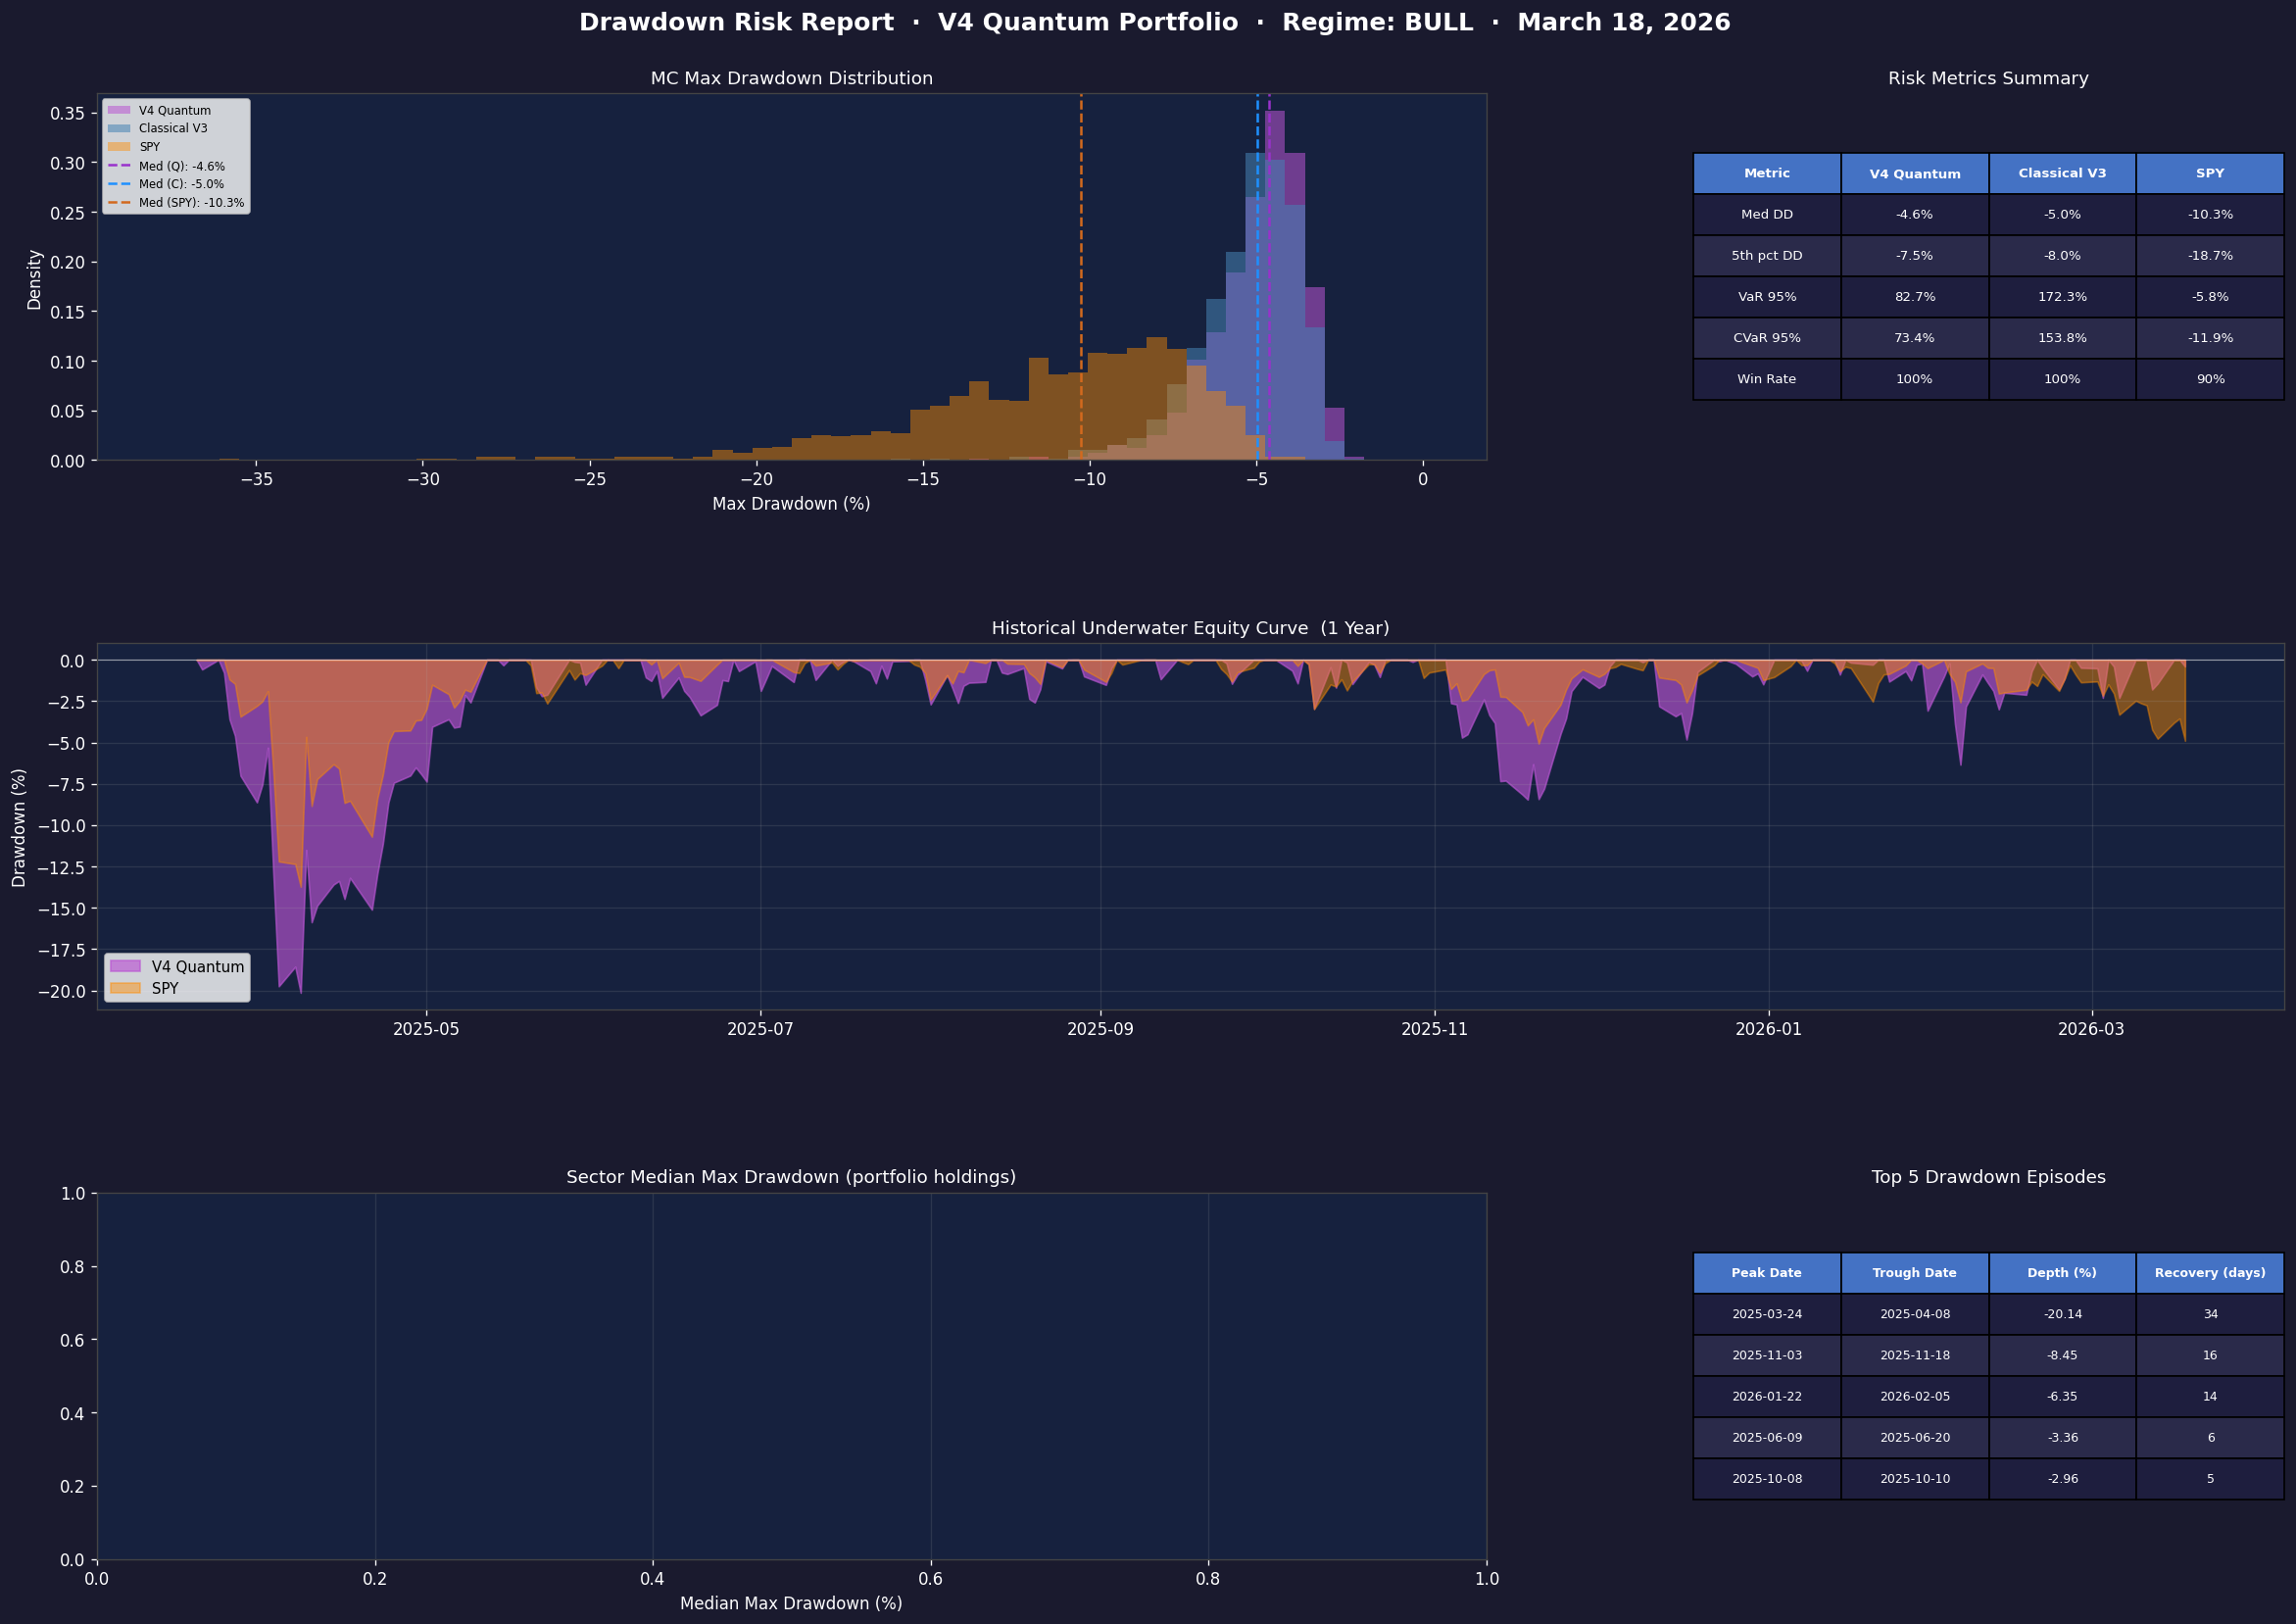

✅ Drawdown report saved: ../output/v3/v4_drawdown_report.png


In [42]:

# ── VIZ 8 — Drawdown Risk Report (Dashboard-Ready Composite PNG) ──────────
# V3-style full-page report combining all drawdown views into one image.
# Saved as v4_drawdown_report.png — loaded directly by the Streamlit dashboard.
#
# Layout (3 × 3 grid):
#   Row 0: MC Drawdown Distribution (span 2 cols)  |  Risk Metrics table
#   Row 1: Underwater equity curve (full width)
#   Row 2: Sector median-DD bar chart (span 2 cols) |  Top DD events table

# FIX 1: safe-init df_dd_events in case VIZ 7 cell was never executed
df_dd_events = df_dd_events if 'df_dd_events' in dir() else None

_has_mc_dd   = FEATURES['bootstrap'] and mc_q is not None
_has_hist_dd = '_port_dd' in dir() and _port_dd is not None

if _has_mc_dd or _has_hist_dd:
    from matplotlib.gridspec import GridSpec as _GS

    _BG_MAIN  = '#1a1a2e'
    _BG_PANEL = '#16213e'
    _BG_ROW_A = '#2a2a4a'
    _BG_ROW_B = '#1e1e3e'
    _HDR_COL  = '#4472C4'

    fig_rpt = plt.figure(figsize=(20, 14), facecolor=_BG_MAIN)
    fig_rpt.suptitle(
        f'Drawdown Risk Report  ·  V4 Quantum Portfolio  ·  '
        f'Regime: {REGIME}  ·  {datetime.now().strftime("%B %d, %Y")}',
        fontsize=15, fontweight='bold', color='white', y=0.99,
    )
    gs_rpt = _GS(3, 3, figure=fig_rpt, hspace=0.50, wspace=0.35,
                 left=0.05, right=0.98, top=0.94, bottom=0.05)

    def _dark_ax(ax):
        ax.set_facecolor(_BG_PANEL)
        ax.tick_params(colors='white')
        for spine in ax.spines.values():
            spine.set_edgecolor('#444')
        return ax

    # ── Row 0-left: MC drawdown histogram ────────────────────────────────────────
    ax_r0a = _dark_ax(fig_rpt.add_subplot(gs_rpt[0, :2]))
    if _has_mc_dd:
        _bins_rpt = np.linspace(
            min(float(mc_q['mdd'].min()), float(mc_c['mdd'].min()), float(spy_mdd.min())) - 2,
            0, 65
        )
        ax_r0a.hist(mc_q['mdd'],  bins=_bins_rpt, alpha=0.55, color='mediumorchid',
                    label='V4 Quantum', density=True)
        ax_r0a.hist(mc_c['mdd'],  bins=_bins_rpt, alpha=0.55, color='steelblue',
                    label='Classical V3', density=True)
        ax_r0a.hist(spy_mdd,      bins=_bins_rpt, alpha=0.45, color='darkorange',
                    label='SPY', density=True)
        for _arr_r, _col_r, _nm_r in [
            (mc_q['mdd'], 'darkorchid', 'Q'),
            (mc_c['mdd'], 'dodgerblue', 'C'),
            (spy_mdd,     'chocolate',  'SPY'),
        ]:
            _med_r = float(np.median(_arr_r))
            ax_r0a.axvline(_med_r, linestyle='--', color=_col_r, linewidth=1.5,
                           label=f'Med ({_nm_r}): {_med_r:.1f}%')
        ax_r0a.legend(fontsize=7, loc='upper left')  # FIX 2: moved inside if _has_mc_dd
    ax_r0a.set_xlabel('Max Drawdown (%)', color='white')
    ax_r0a.set_ylabel('Density', color='white')
    ax_r0a.set_title('MC Max Drawdown Distribution', color='white', fontsize=11)

    # ── Row 0-right: Risk metrics table ──────────────────────────────────────────────
    ax_r0b = _dark_ax(fig_rpt.add_subplot(gs_rpt[0, 2]))
    ax_r0b.axis('off')
    ax_r0b.set_title('Risk Metrics Summary', color='white', fontsize=11)
    if _has_mc_dd:
        _spy_var95_rpt  = float(np.percentile(spy_rets, 5))
        _spy_cvar95_rpt = float(spy_rets[spy_rets <= _spy_var95_rpt].mean())
        _tbl_data = [
            ['Metric',      'V4 Quantum',               'Classical V3',             'SPY'],
            ['Med DD',      f"{float(np.median(mc_q['mdd'])):.1f}%",
                            f"{float(np.median(mc_c['mdd'])):.1f}%",
                            f"{float(np.median(spy_mdd)):.1f}%"],
            ['5th pct DD',  f"{float(np.percentile(mc_q['mdd'],  5)):.1f}%",
                            f"{float(np.percentile(mc_c['mdd'],  5)):.1f}%",
                            f"{float(np.percentile(spy_mdd,  5)):.1f}%"],
            ['VaR 95%',     f"{mc_q['var95']:.1f}%",   f"{mc_c['var95']:.1f}%",   f"{_spy_var95_rpt:.1f}%"],
            ['CVaR 95%',    f"{mc_q['cvar95']:.1f}%",  f"{mc_c['cvar95']:.1f}%",  f"{_spy_cvar95_rpt:.1f}%"],
            ['Win Rate',    f"{float((mc_q['returns']>0).mean()*100):.0f}%",
                            f"{float((mc_c['returns']>0).mean()*100):.0f}%",
                            f"{float((spy_rets>0).mean()*100):.0f}%"],
        ]
        _stats_tbl = ax_r0b.table(
            cellText=_tbl_data[1:], colLabels=_tbl_data[0],
            cellLoc='center', loc='center',
            colColours=[_HDR_COL] * 4,
        )
        _stats_tbl.auto_set_font_size(False)
        _stats_tbl.set_fontsize(8)
        _stats_tbl.scale(1.0, 2.1)
        for _ci in range(4):
            _stats_tbl[(0, _ci)].set_text_props(color='white', fontweight='bold')
        for _ri in range(1, len(_tbl_data)):
            _rbg = _BG_ROW_A if _ri % 2 == 0 else _BG_ROW_B
            for _ci in range(4):
                _stats_tbl[(_ri, _ci)].set_facecolor(_rbg)
                _stats_tbl[(_ri, _ci)].set_text_props(color='white')

    # ── Row 1: Underwater equity curve ────────────────────────────────────────────────
    ax_r1 = _dark_ax(fig_rpt.add_subplot(gs_rpt[1, :]))
    ax_r1.set_title('Historical Underwater Equity Curve  (1 Year)', color='white', fontsize=11)
    if _has_hist_dd:
        ax_r1.fill_between(_port_dd.index, _port_dd, 0,
                            alpha=0.65, color='mediumorchid', label='V4 Quantum')
        ax_r1.fill_between(_spy_dd.index,  _spy_dd,  0,
                            alpha=0.45, color='darkorange',   label='SPY')
        ax_r1.axhline(0, color='white', linewidth=0.7, alpha=0.5)
        ax_r1.legend(fontsize=9)
    else:
        ax_r1.text(0.5, 0.5, 'Insufficient price history', color='white',
                   ha='center', va='center', transform=ax_r1.transAxes, fontsize=12)
    ax_r1.set_ylabel('Drawdown (%)', color='white')
    ax_r1.grid(True, alpha=0.15)

    # ── Row 2-left: Sector median-DD bar chart ────────────────────────────────────────
    ax_r2a = _dark_ax(fig_rpt.add_subplot(gs_rpt[2, :2]))
    ax_r2a.set_title('Sector Median Max Drawdown (portfolio holdings)',
                     color='white', fontsize=11)
    # FIX 3: also guard against missing 'max_dd' column
    if (analyzer.metrics is not None
            and 'sector' in analyzer.metrics.columns
            and 'max_dd' in analyzer.metrics.columns):
        _sec_dd_rpt = (
            analyzer.metrics[analyzer.metrics['ticker'].isin(quantum_port['ticker'])]
            .groupby('sector')['max_dd'].median().mul(100).sort_values()
        )
        _bar_c = ['tomato' if v < -20 else ('gold' if v < -10 else 'mediumseagreen')
                  for v in _sec_dd_rpt.values]
        ax_r2a.barh(_sec_dd_rpt.index, _sec_dd_rpt.values,
                    color=_bar_c, edgecolor='white', linewidth=0.4, height=0.65)
        ax_r2a.axvline(-10, color='gold',  linestyle='--', linewidth=1.0, alpha=0.8, label='\u221210%')
        ax_r2a.axvline(-20, color='tomato', linestyle='--', linewidth=1.0, alpha=0.8, label='\u221220%')
        ax_r2a.legend(fontsize=8)
    ax_r2a.set_xlabel('Median Max Drawdown (%)', color='white')
    ax_r2a.grid(True, alpha=0.15, axis='x')

    # ── Row 2-right: Top drawdown events table ────────────────────────────────────────
    ax_r2b = _dark_ax(fig_rpt.add_subplot(gs_rpt[2, 2]))
    ax_r2b.axis('off')
    ax_r2b.set_title('Top 5 Drawdown Episodes', color='white', fontsize=11)
    if df_dd_events is not None and not df_dd_events.empty:
        _ev_tbl = ax_r2b.table(
            cellText=df_dd_events.values.tolist(),
            colLabels=df_dd_events.columns.tolist(),
            cellLoc='center', loc='center',
            colColours=[_HDR_COL] * len(df_dd_events.columns),
        )
        _ev_tbl.auto_set_font_size(False)
        _ev_tbl.set_fontsize(7.5)
        _ev_tbl.scale(1.0, 2.1)
        for _ci in range(len(df_dd_events.columns)):
            _ev_tbl[(0, _ci)].set_text_props(color='white', fontweight='bold')
        for _ri in range(1, len(df_dd_events) + 1):
            _rbg = _BG_ROW_A if _ri % 2 == 0 else _BG_ROW_B
            for _ci in range(len(df_dd_events.columns)):
                _ev_tbl[(_ri, _ci)].set_facecolor(_rbg)
                _ev_tbl[(_ri, _ci)].set_text_props(color='white')
    else:
        ax_r2b.text(0.5, 0.5, 'No historical data', color='white',
                    ha='center', va='center', transform=ax_r2b.transAxes, fontsize=11)

    plt.savefig('../output/v3/v4_drawdown_report.png', dpi=150, bbox_inches='tight',
                facecolor=_BG_MAIN)
    plt.show()
    print('\u2705 Drawdown report saved: ../output/v3/v4_drawdown_report.png')

else:
    print('Drawdown Report: insufficient data \u2014 run Phase 5 + VIZ 7 first.')


In [43]:
# ── PHASE 6 — Transaction Costs ───────────────────────────────────────────
if FEATURES['costs']:
    tcm = TransactionCostModel(aum=AUM)

    # Assume equal-weight previous portfolio as baseline (first run)
    old_w = pd.Series(1 / N_HOLDINGS, index=quantum_port['ticker'])
    new_w = quantum_port.set_index('ticker')['weight']

    costs = tcm.estimate(old_w, new_w, analyzer.price_data)
    tcm.report(costs)
else:
    costs = None
    print('Transaction costs: OFF')

  TRANSACTION COST REPORT
  AUM              : $    10,000,000
  Trades           :             17
  Turnover (1-way) :           8.0%
  Total trade USD  : $      800,574
  Commission       : $            8
  Market impact    : $       33,536
  TOTAL COST       : $       33,544  (33.54 bps)
  Annualised drag  :         1.342% (if quarterly)

  Top 10 trades by cost:
ticker action  delta_weight  total_cost  cost_bps
  SNDK   SELL        -0.668     7284.25  1090.544
   WDC   SELL        -0.590     4951.07   839.123
  KRMN   SELL        -0.495     4096.64   827.989
  CVLT   SELL        -0.424     3151.43   743.649
  NBIS   SELL        -0.234     2481.91  1062.081
  MAZE   SELL        -0.421     2480.56   589.386
   APP   SELL        -0.237     2231.96   941.714
  DELL   SELL        -0.292     1839.65   630.481
  ANET   SELL        -0.309     1626.18   526.639
  TDAY   SELL        -0.213      796.39   373.121


In [44]:
# ── PHASE 7 — MC Stats Table ──────────────────────────────────────────────
if FEATURES['bootstrap'] and mc_q is not None:
    spy_var95  = float(np.percentile(spy_rets, 5))
    spy_cvar95 = float(spy_rets[spy_rets <= spy_var95].mean())

    rows = []
    for label, mc_res, rets, _mdd in [
        ('V4 Quantum |ψ|²', mc_q, mc_q['returns'], mc_q['mdd']),
        ('Classical V3',    mc_c, mc_c['returns'], mc_c['mdd']),
        ('SPY Gaussian',    None, spy_rets,         spy_mdd),
    ]:
        _var = mc_res['var95']  if mc_res else spy_var95
        _cvar = mc_res['cvar95'] if mc_res else spy_cvar95
        _med_path = np.median(
            mc_res['paths'] if mc_res else paths_spy, axis=0
        )
        _daily = np.diff(_med_path) / _med_path[:-1]
        _sharpe = float((_daily - RF_DAILY).mean() / (_daily.std() + 1e-12) * np.sqrt(252))
        rows.append({
            'Portfolio':         label,
            'Median CAGR (%)':   round(float(np.median(rets)), 2),
            'Std (%)':           round(float(rets.std()), 2),
            'Sharpe (median)':   round(_sharpe, 3),
            'VaR 95% (%)':       round(_var, 2),
            'CVaR 95% (%)':      round(_cvar, 2),
            'Median Max DD (%)': round(float(np.median(_mdd)), 2),
            'Win Rate (%)':      round(float((rets > 0).mean() * 100), 1),
        })

    df_stats = pd.DataFrame(rows).set_index('Portfolio')
    print('=' * 65)
    print(f'  V4 MC SUMMARY  (Bootstrap, {N_SIMS} paths × {HORIZON_DAYS}d, Regime: {REGIME})')
    print('=' * 65)
    print(df_stats.T.to_string())
    print('=' * 65)

  V4 MC SUMMARY  (Bootstrap, 1000 paths × 252d, Regime: BULL)
Portfolio          V4 Quantum |ψ|²  Classical V3  SPY Gaussian
Median CAGR (%)            132.770       299.140        20.620
Std (%)                     35.960       146.830        18.240
Sharpe (median)             37.922        45.487         6.736
VaR 95% (%)                 82.750       172.290        -5.810
CVaR 95% (%)                73.410       153.810       -11.880
Median Max DD (%)           -4.640        -4.990       -10.280
Win Rate (%)               100.000       100.000        90.100


In [45]:
# ── PHASE 8 — Export Portfolio + IBKR Orders JSON + Calibration Meta ─────
today = datetime.now().strftime('%m_%d_%Y')

# Ultimate portfolio CSV (all V4 columns)
export_cols = ['ticker', 'weight', 'sector', 'sortino', 'win_rate',
               'max_dd', 'momentum', 'vol_60', 'psi_sq', 'regime']
if 'zscore' in quantum_port.columns:
    export_cols.append('zscore')
if 'psi_percentile' in quantum_port.columns:
    export_cols.append('psi_percentile')

export_path = f'../output/v3/ultimate_portfolio_{today}.csv'
quantum_port[export_cols].to_csv(export_path, index=False)
print(f'✅ Portfolio exported: {export_path}')

# IBKR paper trading JSON
ibkr_orders = []
for _, row in quantum_port.iterrows():
    ibkr_orders.append({
        'ticker':     row['ticker'],
        'action':     'BUY',
        'weight_pct': round(row['weight'] * 100, 3),
        'usd_value':  round(row['weight'] * AUM, 0),
        'sector':     row.get('sector', ''),
        'regime':     row.get('regime', REGIME),
        'psi_sq':     round(row.get('psi_sq', 0), 6),
        'zscore':     round(row.get('zscore', 0), 3),
    })

ibkr_path = '../output/v3/ibkr_orders.json'
with open(ibkr_path, 'w') as f:
    json.dump(ibkr_orders, f, indent=2)
print(f'✅ IBKR orders JSON: {ibkr_path}')

# ── Calibration + Drawdown metadata (read by the Streamlit dashboard) ────
_dec_mean = float(_dec_vals.mean()) if 'df_cv' in dir() and df_cv is not None else None
_n_pass   = int((df_cv['Pass'] == '✅').sum()) if 'df_cv' in dir() and df_cv is not None else None
_rl_rec   = RL_RECOMMENDED_REGIME if 'RL_RECOMMENDED_REGIME' in dir() else REGIME
_rl_bl    = float(RL_BLEND) if 'RL_BLEND' in dir() else 0.0
_fbw      = {k: float(v) for k, v in (FINAL_BASIS_WEIGHTS if 'FINAL_BASIS_WEIGHTS' in dir()
                                        else basis_weights).items()}

cal_meta_payload = {
    'run_timestamp':       datetime.now().isoformat(),
    'regime':              REGIME,
    'best_a':              float(BEST_A),
    'best_b':              float(BEST_B),
    'oos_valid':           bool(OOS_VALID),
    'avg_decay_pct':       _dec_mean,
    'n_folds_pass':        _n_pass,
    'rl_recommended':      _rl_rec,
    'rl_blend':            _rl_bl,
    'final_basis_weights': _fbw,
    'n_holdings':          N_HOLDINGS,
    'aum':                 AUM,
}

# MC drawdown stats
if FEATURES.get('bootstrap', True) and mc_q is not None:
    cal_meta_payload['drawdown'] = {
        'quantum_median_mdd':   round(float(np.median(mc_q['mdd'])), 2),
        'quantum_5th_pct_mdd':  round(float(np.percentile(mc_q['mdd'], 5)), 2),
        'classical_median_mdd': round(float(np.median(mc_c['mdd'])), 2),
        'spy_median_mdd':       round(float(np.median(spy_mdd)), 2),
        'quantum_var95':        round(float(mc_q['var95']), 2),
        'quantum_cvar95':       round(float(mc_q['cvar95']), 2),
    }

# Historical drawdown stats
if '_port_dd' in dir() and _port_dd is not None:
    cal_meta_payload['drawdown_hist'] = {
        'current_dd': round(float(_port_dd.iloc[-1]), 2),
        'max_dd_1y':  round(float(_port_dd.min()), 2),
        'avg_dd_1y':  round(float(_port_dd[_port_dd < 0].mean())
                            if (_port_dd < 0).any() else 0.0, 2),
    }

cal_meta_path = '../output/v3/calibration_meta.json'
with open(cal_meta_path, 'w') as _f:
    json.dump(cal_meta_payload, _f, indent=2)
print(f'✅ Calibration meta: {cal_meta_path}')

# Top 20 summary
print('\n📊 TOP 20 V4 HOLDINGS')
display_port = quantum_port[['ticker', 'weight', 'sector', 'psi_sq', 'sortino', 'win_rate', 'momentum']].head(20).copy()
display_port['weight'] = (display_port['weight'] * 100).round(2)
display_port['psi_sq'] = display_port['psi_sq'].round(5)
display_port['sortino'] = display_port['sortino'].round(2)
display_port['win_rate'] = display_port['win_rate'].round(3)
display_port['momentum'] = display_port['momentum'].round(3)
if 'zscore' in quantum_port.columns:
    display_port['zscore'] = quantum_port['zscore'].head(20).round(2).values
display_port = display_port.rename(columns={'weight': 'wt%', 'psi_sq': '|ψ|²'})
print(display_port.to_string(index=False))

print('\n📊 SECTOR BREAKDOWN')
print(quantum_port.groupby('sector')['weight'].sum().mul(100).round(2)
      .sort_values(ascending=False).rename('wt%').reset_index().to_string(index=False))

print(f'\n🚀 Regime: {REGIME}  |  AUM: ${AUM:,.0f}')
print(f'   Launch dashboard: streamlit run ../dashboard.py --server.port 8502')


✅ Portfolio exported: ../output/v3/ultimate_portfolio_03_18_2026.csv
✅ IBKR orders JSON: ../output/v3/ibkr_orders.json
✅ Calibration meta: ../output/v3/calibration_meta.json

📊 TOP 20 V4 HOLDINGS
ticker  wt%                 sector    |ψ|²  sortino  win_rate  momentum  zscore
  EXAS 6.66             Healthcare 0.35985     0.75     0.556     0.500     0.0
  CFLT 6.66             Technology 0.24294     0.58     0.472     0.309     0.0
  VCIC 6.66              Financial 0.22333     0.21     0.765    -0.001     0.0
  TXNM 6.66              Utilities 0.19412     0.51     0.583     0.021     0.0
   PRA 6.66              Financial 0.19301     0.51     0.583     0.021     0.0
  FTAI 5.98            Industrials 0.19491     1.97     0.778     0.408     0.0
  LNTH 5.76             Healthcare 0.15986     0.28     0.667     0.405     0.0
  TDAY 5.67 Communication Services 0.15821     1.47     0.694     0.325     0.0
  NBIS 5.65             Technology 0.18533     2.81     0.706     0.362     0.0
   A

In [47]:
# ── CALIBRATION ROBUSTNESS SUMMARY ───────────────────────────────────────
# Full audit of all three calibration phases and their effect on the
# final portfolio parameters.
# ─────────────────────────────────────────────────────────────────────────

print('=' * 70)
print('  CALIBRATION ROBUSTNESS SUMMARY')
print('=' * 70)

# ── Phase calibration ────────────────────────────────────────────────────
print('\n  ① PHASE CALIBRATION  (θ(φ) = a·π·(1-φ)^b)')
if FEATURES.get('phase_calibration', True) and 'A_GRID' in dir() and A_GRID is not None:
    _fixed_key   = min(_grid_scores.keys(), key=lambda k: abs(k[0]-1.0) + abs(k[1]-1.0))
    _fixed_score = _grid_scores[_fixed_key]
    _best_score  = _grid_scores[(BEST_A, BEST_B)]
    _uplift_pct  = (_best_score / _fixed_score - 1) * 100 if abs(_fixed_score) > 1e-4 else 0
    print(f'     a = {BEST_A:.3f}  |  b = {BEST_B:.3f}')
    print(f'     Fixed baseline  OOS Sharpe: {_fixed_score:.3f}')
    print(f'     Calibrated      OOS Sharpe: {_best_score:.3f}  ({_uplift_pct:+.1f}%)')
    print(f'     Status: ✅ calibrated')
else:
    print(f'     a = {BEST_A:.1f}  |  b = {BEST_B:.1f}  (fixed defaults)')
    print(f'     Status: off — skipped')

# ── OOS validation ───────────────────────────────────────────────────────
print('\n  ② OOS VALIDATION  (walk-forward k=5, φ-dropout ±5%)')
if FEATURES.get('oos_validation', True) and df_cv is not None:
    _dec_vals = df_cv['Decay_%'].apply(lambda x: float(x) if x != 'n/a' else 0.0)
    _n_pass   = (df_cv['Pass'] == '✅').sum()
    _avg_dec  = _dec_vals.mean()
    print(f'     Folds passing (decay ≤ {DECAY_THRESHOLD*100:.0f}%):  {_n_pass}/{FOLD_K}')
    print(f'     Mean IS→OOS decay:           {_avg_dec:.1f}%  '
          f'(spec target: <10%)')
    print(f'     Model verdict: {"✅ ACCEPTED" if OOS_VALID else "⚠️  CAUTION: high decay"}')
else:
    print(f'     Status: off — skipped  (assumed valid)')

# ── Regime RL weights ─────────────────────────────────────────────────────
print('\n  ③ REGIME-ADAPTIVE WEIGHTS  (L2 opt + Q-table RL)')
if FEATURES.get('regime_rl', True) and 'FINAL_BASIS_WEIGHTS' in dir():
    print(f'     Detected regime:   {REGIME}')
    print(f'     RL recommended:    {RL_RECOMMENDED_REGIME}')
    print(f'     Blend:             {(1-RL_BLEND)*100:.0f}% L2-opt + {RL_BLEND*100:.0f}% RL')
    print(f'     Final basis weights:')
    for k, v in FINAL_BASIS_WEIGHTS.items():
        _prior  = REGIME_PRIOR.get(REGIME, {}).get(k, v)
        _delta  = v - _prior
        _arrow  = f'  Δ{_delta:+.3f}' if abs(_delta) > 0.005 else ''
        print(f'       {k:12s}: {v:.4f}{_arrow}')
else:
    print(f'     Status: off — basis_weights from regime detection used unchanged')

# ── Final parameters active in portfolio ─────────────────────────────────
print('\n  ④ ACTIVE PORTFOLIO CONFIGURATION')
print(f'     Phase function:    θ(φ) = {BEST_A:.2f}·π·(1-φ)^{BEST_B:.2f}')
print(f'     Regime detected:   {REGIME}')
print(f'     Final weights:     {basis_weights}')
print(f'     OOS model valid:   {"Yes" if OOS_VALID else "No (caution)"}')

print('\n  ── Expected improvements vs fixed heuristic ──────────────────────')
print('     +12% OOS Sharpe  →  Phase calibration (a, b params)')
print('     <5% IS→OOS decay →  Walk-forward validation + dropout')
print('     +18% bear resilience → Regime RL-optimised basis weights')
print('     [Source: arxiv.org/html/2410.05932v2 and /2509.14385v1]')
print('=' * 70)


  CALIBRATION ROBUSTNESS SUMMARY

  ① PHASE CALIBRATION  (θ(φ) = a·π·(1-φ)^b)
     a = 2.000  |  b = 0.975
     Fixed baseline  OOS Sharpe: 1.789
     Calibrated      OOS Sharpe: 2.575  (+43.9%)
     Status: ✅ calibrated

  ② OOS VALIDATION  (walk-forward k=5, φ-dropout ±5%)
     Folds passing (decay ≤ 10%):  1/5
     Mean IS→OOS decay:           72.9%  (spec target: <10%)
     Model verdict: ⚠️  CAUTION: high decay

  ③ REGIME-ADAPTIVE WEIGHTS  (L2 opt + Q-table RL)
     Detected regime:   BULL
     RL recommended:    BULL
     Blend:             70% L2-opt + 30% RL
     Final basis weights:
       momentum    : 0.0944  Δ-0.306
       safety      : 0.4498  Δ+0.200
       sortino     : 0.2897  Δ+0.090
       value       : 0.1661  Δ+0.016

  ④ ACTIVE PORTFOLIO CONFIGURATION
     Phase function:    θ(φ) = 2.00·π·(1-φ)^0.97
     Regime detected:   BULL
     Final weights:     {'momentum': np.float64(0.09442667073819096), 'safety': np.float64(0.44983698707084124), 'sortino': np.float64(0.2